In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import re

from tqdm import tqdm
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score
from collections import defaultdict
from numpy.linalg import norm
from poincare import PoincareManifold
from model import Distance_PE
from data import G_hpo
from frechetmean import frechet_mean
from OT_utils import *
from data_utils import *

In [2]:
# Modifier à chaque fois :
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)

objects = checkpoint['objects']
node2id = checkpoint['node2id']
losses = checkpoint['losses']
norm_history = checkpoint['norm_history']
edges_closed = checkpoint['edges']
data = checkpoint['data']
hp = checkpoint['hyperparams']

edges = np.array([(node2id[u], node2id[v]) for u, v in G_hpo.edges()],dtype=np.int64)


In [3]:
print(hp)

{'dim': 15, 'epochs': 1500, 'lr': 1.6, 'burnin': 100, 'n_neg': 100}


In [3]:
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [4]:
W = model.weight.detach().cpu().numpy()   # (N, dim)
norms = np.linalg.norm(W, axis=1)

print(f"Modèle chargé — {len(objects)} nœuds | dim={hp['dim']} | "
      f"{len(losses)} epochs")
print(f"Norme moy={norms.mean():.4f} | max={norms.max():.4f}")

i_min = np.argmin(norms).item()
print(f"Index de la plus petite norme : {i_min}")
print(f"Position du point : {W[i_min]}")


Modèle chargé — 19389 nœuds | dim=15 | 1500 epochs
Norme moy=0.9640 | max=0.9900
Index de la plus petite norme : 101
Position du point : [-0.02290159  0.00820978 -0.00655441  0.00533598 -0.02455972 -0.06093883
 -0.00785416  0.03578258 -0.01433282  0.04514984  0.00592283 -0.01020399
 -0.04606588  0.02117609  0.04252743]


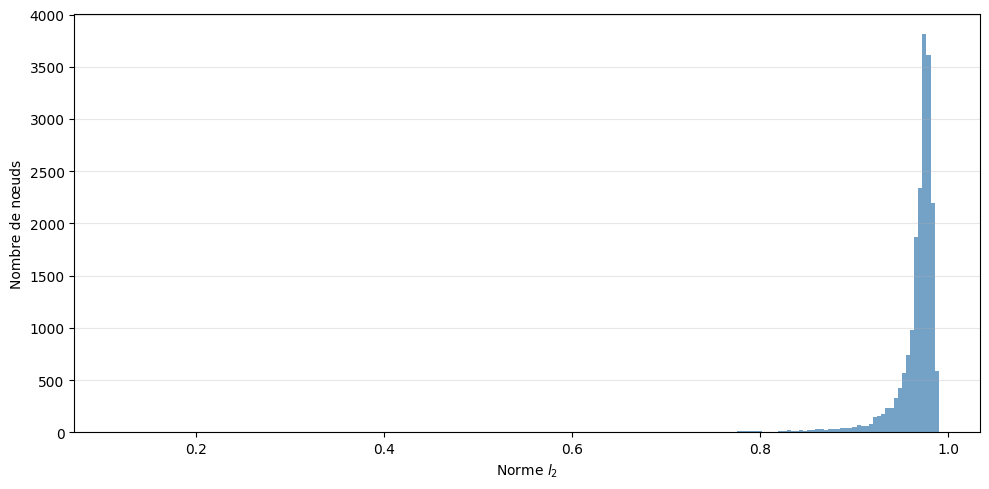

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(norms, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Norme $l_2$")
ax.set_ylabel("Nombre de nœuds")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Correlation degré/norme l2
degrees = np.array([len(data.pos_neighbors[i]) for i in range(len(objects))])
norms = model.weight.detach().norm(dim=-1).numpy()

# Corrélation degré/norme attendue : négative
rho, pval = spearmanr(degrees, norms)
print(f"Corrélation Spearman degré/norme : {rho:.3f} (p={pval:.2e})")
print(np.unique(degrees))

Corrélation Spearman degré/norme : 0.196 (p=8.50e-168)
[0 1 2 3 4 5]


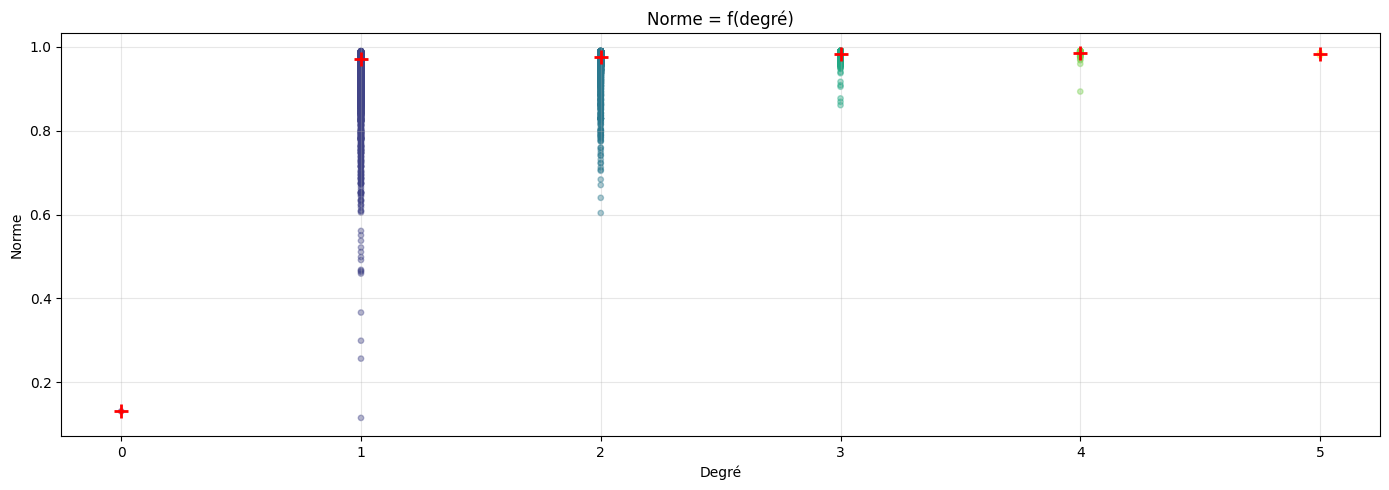

In [9]:
fig, ax = plt.subplots(1, figsize=(14, 5))

sc = ax.scatter(degrees, norms, alpha=0.4, s=15, c=degrees)

# Moyenne des normes de même profondeur
for d in np.unique(degrees):
    mask = degrees == d
    ax.plot(d, np.median(norms[mask]), 'r+', markersize=10, markeredgewidth=2)

ax.set_xlabel("Degré")
ax.set_ylabel("Norme")
ax.set_title("Norme = f(degré)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
depths = compute_depths(objects, data)
rho, pval = spearmanr(depths, norms)
print(f"Corrélation Spearman profondeur/norme : {rho:.3f} (p={pval:.2e})")

[0]
Corrélation Spearman profondeur/norme : -0.526 (p=0.00e+00)


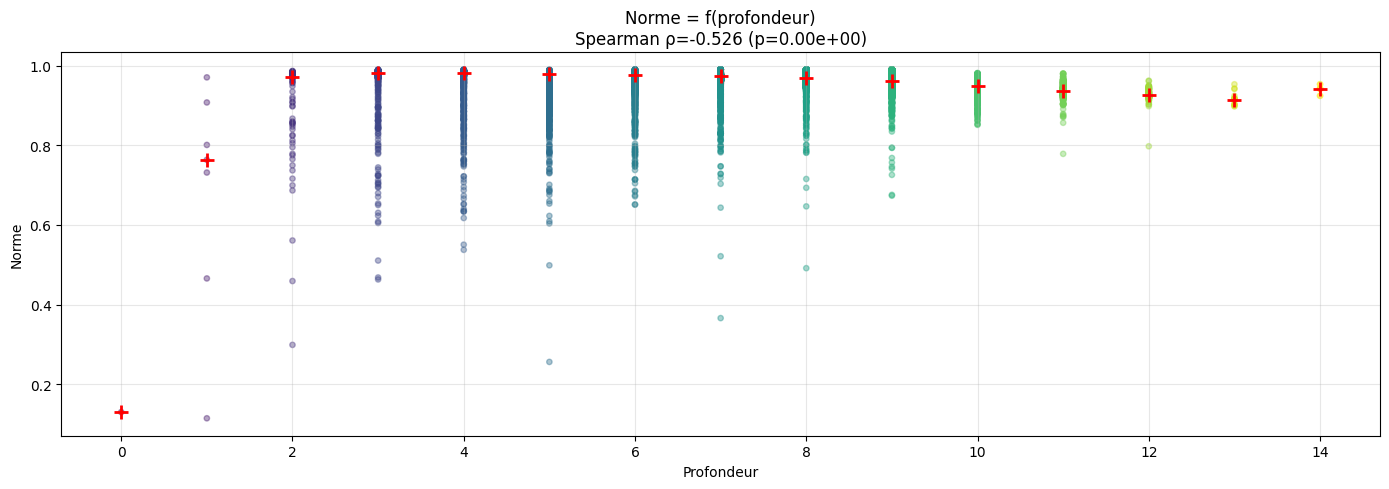

In [ ]:
fig, ax = plt.subplots(1, figsize=(14, 5))

sc = ax.scatter(depths, norms, alpha=0.4, s=15, c=depths, cmap='viridis')

# Moyenne des normes de même profondeur
for d in np.unique(depths):
    mask = depths == d
    ax.plot(d, np.median(norms[mask]), 'r+', markersize=10, markeredgewidth=2)

ax.set_xlabel("Profondeur")
ax.set_ylabel("Norme")
ax.set_title(f"Norme = f(profondeur)\nSpearman ρ={rho:.3f} (p={pval:.2e})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# La corrélation de Spearman négative à une p-valeur nulle, donc est significative à tous les seuils
# de confiance, néanmoins cela ne semble pas évident lorsque l'on regarde le graphe. Une corrélation
# négative indiquerait qu'une plus grande profondeur dans l'arbre est associée à une moindre norme,
# ce qui peut paraître contre-intuitif.

In [6]:
pos_neighbors = defaultdict(set)
pos_parents = defaultdict(set)

for u, v in edges:
    pos_neighbors[int(u)].add(int(v))
    pos_parents[int(v)].add(int(u))
    
len(pos_parents[i_min])
len(pos_parents[0])

7

In [20]:
degrees = np.array([len(data.pos_neighbors[i]) for i in range(len(objects))])

# Top 10 plus proches du centre
center_ids = np.argsort(norms)[:10]
print("=== 10 nœuds les plus proches du CENTRE ===")
for i in center_ids:
    print(f"  {objects[i]:<30} norme={norms[i]:.4f}  degré={degrees[i]}")

# Top 10 plus proches du bord
border_ids = np.argsort(norms)[-10:]
print("\n=== 10 nœuds les plus proches du BORD ===")
for i in border_ids:
    print(f"{objects[i]:<30} norme={norms[i]:.4f}  degré={degrees[i]}")
print(f"\nNombre de noeuds exactement au bord de la boule : {len([objects[i] for i in range(len(norms)) if norms[i]==0.990])}/{len(objects)}")

=== 10 nœuds les plus proches du CENTRE ===
  HP:0000118                     norme=0.1144  degré=1
  HP:0000001                     norme=0.1300  degré=0
  HP:0012649                     norme=0.2559  degré=1
  HP:0001939                     norme=0.2987  degré=1
  HP:0000163                     norme=0.3659  degré=1
  HP:0000818                     norme=0.4590  degré=1
  HP:0011793                     norme=0.4630  degré=1
  HP:0012823                     norme=0.4656  degré=1
  HP:0012638                     norme=0.4680  degré=1
  HP:0011001                     norme=0.4913  degré=1

=== 10 nœuds les plus proches du BORD ===
HP:0009509                     norme=0.9900  degré=3
HP:0009632                     norme=0.9900  degré=4
HP:0009535                     norme=0.9900  degré=2
HP:0009517                     norme=0.9900  degré=3
HP:0009529                     norme=0.9900  degré=3
HP:0009533                     norme=0.9900  degré=3
HP:0009669                     norme=0.9900  

In [14]:
@torch.no_grad()
def evaluate(model, objects, edges, node2id):
    model.eval()
    W = model.weight.to(device)
    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))

    ranksum, ap_scores = 0, 0
    nranks = 0
    iters = 0
    labels = np.empty(model.embeddings.weight.size(0))
 
    for u in tqdm(objects):
        labels.fill(0)
        u = int(node2id[u])
        neighbors = pos_neighbors.get(u, set())
        if not neighbors :
            continue
        u_exp = W[u].unsqueeze(0).expand(W.shape[0], -1)  # Coordonnées de u dans la boule de Poincaré
        dists = manifold.distance(u_exp, W, 1).numpy()  # Distance de Poincaré de u aux autres noeuds
        dists[u] = 1e12
        #order = np.argsort(dists)  # Tri par distance décroissante p/r à u
        sorted_ind = np.argsort(dists)

        #ranks = int(np.where(order == v)[0][0]) + 1  # Rang du noeud v p/r à u dans l'embedding
        #ranks.append(rank)
        ranks, = np.where(np.isin(sorted_ind, list(neighbors)))
        ranks += 1
        N = ranks.shape[0]

        ranksum += ranks.sum() - (N * (N - 1) / 2)
        nranks += ranks.shape[0]
        labels[list(neighbors)] = 1
        ap_scores += average_precision_score(labels, -dists)
        iters += 1

        #pos  = pos_neighbors[u]  # Voisins de u dans la représentation initiale
        #hits, psum = 0, 0.0 
        #for k, idx in enumerate(order[1:], 1):  # On parcourt les noeuds du plus proche au plus éloigné
            #if idx in pos:
                #hits  += 1
                #psum  += hits / k
        #aps.append(psum / max(len(pos), 1))
 
    return float(ranksum), nranks, ap_scores, iters

In [6]:
objects_hpo = list(G_hpo.nodes())
node2id_hpo = {n: i for i, n in enumerate(objects_hpo)}
edges_hpo = np.array([(node2id_hpo[v], node2id_hpo[u]) for u, v in G_hpo.edges()],dtype=np.int64)
new_edges = [(v, u) for u, v in edges]
results = evaluate(model.weight.detach().cpu(), objects, new_edges, node2id)

print("Erreur moyenne sur le rang : ", float(results[0]) / results[1])
print("Mean Average Precision :", float(results[2]) / results[3])

AttributeError: 'Tensor' object has no attribute 'eval'

In [11]:
@torch.no_grad()
def evaluate2(model, objects, edges, node2id, device):
    """
    Retourne MAP et mean rank.
    Corrige : distance avec model.c, calcul GPU, pas de fuite u dans le ranking.
    """
    model.eval()
    W = model.weight.to(device)  # (N, dim)

    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))

    ap_scores = []
    ranks_all = []
    N = W.shape[0]
    labels = np.zeros(N)

    for obj in tqdm(objects):
        u = int(node2id[obj])
        neighbors = pos_neighbors.get(u, set())
        if not neighbors:
            continue

        # Distances GPU avec la bonne courbure
        u_emb = W[u].unsqueeze(0).expand(N, -1)   # (N, dim)
        dists = model.manifold.distance(u_emb, W, model.c)  # (N,)
        dists[u] = float('inf')                    # exclure u lui-même
        dists_np = dists.cpu().numpy()

        max_finite = dists_np[np.isfinite(dists_np)].max()
        dists_np[~np.isfinite(dists_np)] = max_finite + 1.0

        # Rang des voisins
        sorted_ind = np.argsort(dists_np)
        ranks = np.where(np.isin(sorted_ind, list(neighbors)))[0] + 1
        # Correction : soustraire les rangs des autres voisins placés avant
        n_neighbors = len(neighbors)
        corrected_ranks = ranks - np.arange(n_neighbors)
        ranks_all.extend(corrected_ranks.tolist())

        # AP
        labels.fill(0)
        labels[list(neighbors)] = 1
        ap_scores.append(average_precision_score(labels, -dists_np))

    map_score  = float(np.mean(ap_scores))
    mean_rank  = float(np.mean(ranks_all))

    model.train()
    return map_score, mean_rank

In [12]:
results = evaluate2(model, objects, new_edges, node2id, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

results

100%|██████████| 19389/19389 [00:27<00:00, 710.86it/s] 


(0.7653385461399612, 411.49415044135657)

## Calcul de l'*information content* (des poids pour les barycentres)

In [5]:
profils_omim = pd.read_csv("../data/profils_omim.csv.gz", index_col=0)
profils_omim = profils_omim.reset_index()

/tmp/ipykernel_1749/2817799710.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [ ]:
hp_ids = []
parents_list = []

with open("../data/HPOs.csv", "r") as f:
    next(f)
    for line in f:
        hp_id = line.split(';')[0]
        
        # Extraire uniquement la liste contenant des IDs HP:XXXXXXX
        match = re.search(r"\[([^\]]*'HP:\d{7}'[^\]]*)\]", line)
        if match:
            parents = re.findall(r"HP:\d{7}", match.group(0))
        else:
            parents = []
        
        hp_ids.append(hp_id)
        parents_list.append(parents)

df_hpo = pd.DataFrame({'hp_id': hp_ids, 'parents': parents_list})

# Vérification
print(repr(df_hpo['hp_id'].iloc[1]))
print(df_hpo['parents'].iloc[1])
print(df_hpo['parents'].iloc[7])

'HP:0000002'
['HP:0001507']
['HP:0000014']


In [7]:
G_hpo_work = nx.DiGraph()
for hp_id in hp_ids:
    G_hpo_work.add_node(hp_id)
for hp_id, parents in zip(hp_ids, parents_list):
    for parent_id in parents:
        if parent_id in G_hpo_work:
            G_hpo_work.add_edge(hp_id, parent_id)

objects_w = list(G_hpo_work.nodes())
node2id_w = {n: i for i, n in enumerate(objects)}

# Vérification
print([repr(n) for n in list(G_hpo_work.nodes)[:3]])
print("Ancêtres HP:6001462:", list(nx.ancestors(G_hpo_work, 'HP:6001462')))

["'HP:0000001'", "'HP:0000002'", "'HP:0000003'"]
Ancêtres HP:6001462: []


In [ ]:
deprecated={
    'HP:0006887':'HP:0001249',
    'HP:0002275':'HP:0002311',
    'HP:0002370':'HP:0002311',
    'HP:0002438':'HP:0001317',
    'HP:0004059':'HP:0006433',
    'HP:0005365':'HP:0010976',
    'HP:0005435':'HP:0011840',
    'HP:0005807':'HP:0009881',
    'HP:0007543':'HP:0000962',
    'HP:0007680':'HP:0007894',
    'HP:0007850':'HP:0030666',
    'HP:0007898':'HP:0012231',
    'HP:0009062':'HP:0008936',
    'HP:0010064':'HP:0010091',
    'HP:0012178':'HP:0012177',
    'HP:0030050':'HP:0002524',  # Suspect
    'HP:0031014':'HP:0031632',
    'HP:0100786':'HP:0001262',
    'HP:0200065':'HP:0000533'
}

# Test
print(get_ancestors0(G_hpo_work, 'HP:0000253'))
# doit donner {HP:0005484, HP:0000252, ..., HP:0000001}

def compute_information_content(df_omim, G_hpo, deprecated):
    colnames = df_omim.columns[1:]
    weights = defaultdict(float)
    diseases = defaultdict(set)
    all_diseases = defaultdict(set)
    ancestors = {}

    def get_ancestors(term):
        if term not in ancestors:
            ancestors[term]=get_ancestors0(G_hpo, term)
        return ancestors[term]

    for id, row in df_omim.iterrows():
        for term in colnames:
            if row[term]==1:
                resolved = deprecated.get(term, term)
                weights[resolved]+=1
                diseases[resolved].add(id)
                all_diseases[resolved].add(id)
                for ancestor in get_ancestors(resolved):
                    weights[ancestor]+=1
                    all_diseases[ancestor].add(id)
    total = sum(weights.values())
    return {t: w / total for t, w in weights.items()}, diseases, all_diseases


{'HP:0000252', 'HP:0000152', 'HP:0002011', 'HP:0007364', 'HP:0009121', 'HP:0000929', 'HP:0033127', 'HP:0000118', 'HP:0000001', 'HP:0002977', 'HP:0040195', 'HP:0012443', 'HP:0000924', 'HP:0002060', 'HP:0011842', 'HP:0000234', 'HP:0000707', 'HP:0100547', 'HP:0005484', 'HP:0000240', 'HP:0012639'}


In [9]:
hpo_cols = [col for col in profils_omim.columns if col.startswith("HP:")]
manquants = [col for col in hpo_cols if col not in G_hpo]
print(f"{len(manquants)} termes absents du graphe : {manquants}")

19 termes absents du graphe : ['HP:0002275', 'HP:0002370', 'HP:0002438', 'HP:0004059', 'HP:0005365', 'HP:0005435', 'HP:0005807', 'HP:0006887', 'HP:0007543', 'HP:0007680', 'HP:0007850', 'HP:0007898', 'HP:0009062', 'HP:0010064', 'HP:0012178', 'HP:0030050', 'HP:0031014', 'HP:0100786', 'HP:0200065']


In [10]:
weights, diseases, all_diseases = compute_information_content(profils_omim, G_hpo_work, deprecated)
# Vérification
sum(weights.values())

1.0

In [11]:
def inspect_weights(weights, disease, all_disease, G_hpo, top_n=20):
    roots = [n for n in G_hpo.nodes if G_hpo.out_degree(n) == 0]
    root = roots[0] if roots else None

    G_inv = G_hpo.reverse()
    if root:
        depths = nx.single_source_shortest_path_length(G_inv, root)
    else:
        depths = {}

    rows = []
    for term, weight in weights.items():
        n_ancestors = len(get_ancestors0(G_hpo, term))
        n_children  = G_hpo.in_degree(term)
        rows.append({
            'term'       : term,
            'weight'     : weight,
            'depth'      : depths.get(term, -1),
            'n_ancestors': n_ancestors,
            'n_children' : n_children,
            'n_diseases' : len(disease.get(term, set())) if term in disease else 0,
            'n_diseases tot':len(all_disease.get(term, set())) if term in all_disease else 0
        })

    df = (pd.DataFrame(rows)
            .sort_values('weight', ascending=False)
            .reset_index(drop=True))

    df.index += 1
    df['weight'] = df['weight'].map('{:.6f}'.format)

    print(f"Racine détectée : {root}")
    print(f"Termes : {len(weights)}\n")
    print(df.head(top_n).to_string())
    return df

df_inspect = inspect_weights(weights, diseases, all_diseases, G_hpo_work, top_n=20)

Racine détectée : HP:0000001
Termes : 5674

          term    weight  depth  n_ancestors  n_children  n_diseases  n_diseases tot
1   HP:0000118  0.139856      1            1          23        6139            6139
2   HP:0000001  0.139856      0            0           7           0            6139
3   HP:0000707  0.033079      2            2           3        3877            3936
4   HP:0033127  0.030582      2            2           4        3798            3882
5   HP:0000924  0.021063      3            3           4        3005            3106
6   HP:0012638  0.020213      3            3          28        3581            3627
7   HP:0011842  0.019454      4            4          23        2899            2986
8   HP:0000152  0.016285      2            2           2        2828            3072
9   HP:0000234  0.015033      3            3           6        2781            3029
10  HP:0040064  0.011963      2            2          14        2184            2204
11  HP:0012639  0.011

'*HP:0000001*' correspond à la racine (et n'est pas présent dans `profils_omim`) et '*HP:0000118*' correspond à la catégorie *Phenotypic abnormality*, il est donc cohérent qu'elles aient les comptes les plus élevés, égaux au nombre de maladies.

## Représentation des maladies dans l'embeddings

On souhaite d'abord :
- visualiser pour une maladie les termes HPO dans l'*embedding* obtenu ;
- avoir une métrique résumant à quel point les termes HPO d'une même maladies sont éloignés les uns des autres dans l'*embedding* obtenu.

Dans un second temps, on calculera le barycentre des termes HPO pour chaque maladie, afin d'avoir une représentation synthétique de ces dernières, en pondérant :
- soit uniformément ;
- soit avec l'inverse des poids calculés précédemment (*information content*).

In [12]:
from itertools import combinations

def disease_hpo_distances(disease_id, profils_omim, node2id, deprecated=deprecated):

    row = profils_omim.loc[disease_id]
    hpo_cols = profils_omim.columns[1:]
    active_terms = f_active_terms(row, hpo_cols, node2id, deprecated)

    if len(active_terms) < 2:
        print(f"Strictement moins de 2 termes HPO pour {disease_id}")
        return None
    model.eval()
    W = model.weight.detach().cpu().numpy()
    embs = np.array([W[node2id[t]] for t in active_terms])

    # Calculer toutes les distances par paires
    pairs = list(combinations(range(len(active_terms)), 2))
    distances = {}
    manifold=PoincareManifold()
    for i, j in pairs:
        u = torch.tensor(embs[i], dtype=torch.float64)
        v = torch.tensor(embs[j], dtype=torch.float64)
        d = manifold.distance(u, v, c=1).item()
        distances[(active_terms[i], active_terms[j])] = d

    dist_values = np.array(list(distances.values()))

    stats = {
        'disease'   : disease_id,
        'n_terms'   : len(active_terms),
        'mean_dist' : dist_values.mean(),
        'max_dist'  : dist_values.max(),
        'min_dist'  : dist_values.min(),
        'std_dist'  : dist_values.std(),
    }

    return active_terms, embs, distances, stats

In [14]:
# Exemple
active_terms, embs, distances, stats = disease_hpo_distances(3, profils_omim, node2id_w)
stats

{'disease': 3,
 'n_terms': 55,
 'mean_dist': np.float64(5.523257728965684),
 'max_dist': np.float64(9.16883064934852),
 'min_dist': np.float64(0.00031792342844160594),
 'std_dist': np.float64(1.8059151205052413)}

In [22]:
def compute_all_distances(profils_omim, node2id, deprecated=deprecated):
    hpo_cols = profils_omim.columns[1:]
    results = []

    model.eval()
    W = model.weight.detach().cpu().numpy()
    manifold=PoincareManifold()

    col_to_idx = {}
    for col in hpo_cols:
        resolved = deprecated.get(col, col)
        if resolved in node2id:
            col_to_idx[col] = node2id[resolved]

    valid_cols = [col for col in hpo_cols if col in col_to_idx]
    col_ids = torch.tensor([col_to_idx[col] for col in valid_cols], dtype=torch.long)

    M = torch.tensor(profils_omim[valid_cols].values, dtype=torch.bool)
    E = W[col_ids]

    names = profils_omim.iloc[:, 0].tolist()
    print(names)

    for (disease_id, name), row_mask in tqdm(zip(zip(profils_omim.index, names), M),total=len(profils_omim)):
        idx = row_mask.nonzero(as_tuple=True)[0]
        if len(idx) < 2:
            continue
        embs = E[idx]
        n = len(embs)
        ii, jj = torch.triu_indices(n, n, offset=1)
        dists = manifold.distance(torch.tensor(embs[ii], dtype=torch.float64), torch.tensor(embs[jj], dtype=torch.float64), c=1.)
        dists = np.array(dists)
        results.append({
            'disease': disease_id,
            'name': name,
            'n_terms': n,
            'sum': dists.sum(),
            'mean_dist': dists.mean(),
            'max_dist': dists.max(),
            'min_dist': dists.min(),
            'std_dist': dists.std(),
        })

    return pd.DataFrame(results).reset_index(drop=True)

omim_distances = compute_all_distances(profils_omim, node2id_w)
omim_distances.to_csv("../data/omim_distances.csv", index=False)        

['A2ML1 (OMIM:166760)', 'AAAS (OMIM:231550)', 'AAGAB (OMIM:148600)', 'AARS1 (OMIM:613287)', 'AARS1 (OMIM:616339)', 'AARS1 (OMIM:619661)', 'AARS1 (OMIM:619691)', 'AARS2 (OMIM:614096)', 'AARS2 (OMIM:615889)', 'AASS (OMIM:238700)', 'ABAT (OMIM:613163)', 'ABCA1 (OMIM:205400)', 'ABCA1 (OMIM:604091)', 'ABCA12 (OMIM:242500)', 'ABCA12 (OMIM:601277)', 'ABCA2 (OMIM:618808)', 'ABCA3 (OMIM:610921)', 'ABCA4 (OMIM:153800)', 'ABCA4 (OMIM:248200)', 'ABCA4 (OMIM:601718)', 'ABCA4 (OMIM:604116)', 'ABCA5 (OMIM:135400)', 'ABCA7 (OMIM:608907)', 'ABCB1 (OMIM:612244)', 'ABCB11 (OMIM:601847)', 'ABCB11 (OMIM:605479)', 'ABCB4 (OMIM:600803)', 'ABCB4 (OMIM:602347)', 'ABCB4 (OMIM:614972)', 'ABCB6 (OMIM:609153)', 'ABCB6 (OMIM:614497)', 'ABCB6 (OMIM:615402)', 'ABCB7 (OMIM:301310)', 'ABCC1 (OMIM:618915)', 'ABCC2 (OMIM:237500)', 'ABCC6 (OMIM:177850)', 'ABCC6 (OMIM:614473)', 'ABCC8 (OMIM:240800)', 'ABCC8 (OMIM:256450)', 'ABCC8 (OMIM:610374)', 'ABCC8 (OMIM:618857)', 'ABCC9 (OMIM:239850)', 'ABCC9 (OMIM:608569)', 'ABCC9 (O

  0%|          | 0/6139 [00:00<?, ?it/s]/tmp/ipykernel_1772/688155809.py:32: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dists = np.array(dists)
100%|██████████| 6139/6139 [01:06<00:00, 92.78it/s] 


In [9]:
def compute_disease_barycenters(profils_omim,node2id, deprecated=deprecated, weights=None, normalize=False, c=1):
    
    model.eval()
    W = model.weight.detach().cpu()

    hpo_cols = profils_omim.columns[1:]

    col_meta = {}
    for col in hpo_cols:
        resolved = deprecated.get(col, col)
        if resolved in node2id:
            w = weights[resolved] if (weights is not None and resolved in weights) else 1.0
            col_meta[col]=(W[node2id[resolved]], w)

    valid_cols = list(col_meta.keys())

    barycenters = []
    for _, row in tqdm(profils_omim.iterrows(), total=len(profils_omim), desc="Barycentres"):
        active = [(col_meta[col][0], col_meta[col][1])
                  for col in valid_cols if row[col] == 1]

        if len(active) < 1:
            barycenters.append(None)
            continue

        points  = torch.stack([a[0] for a in active])
        if weights is None:
            w = None
        else:
            w = torch.tensor([a[1] for a in active], dtype=torch.float32)
            if normalize:
                w = w / w.sum()
 
        barycenter = frechet_mean(points,c, w)
        barycenters.append(barycenter.numpy())

    profils_omim['barycenter'] = barycenters
    return profils_omim
 

In [12]:
profils_test = profils_omim.copy()
profils_test = compute_disease_barycenters(profils_test, node2id_w)

Barycentres: 100%|██████████| 6139/6139 [01:47<00:00, 57.08it/s]


In [13]:
inv_weights = {t: 1/w for t, w in weights.items()}
profils_test_weight = profils_omim.copy()
profils_test_weight = compute_disease_barycenters(profils_test_weight, node2id_w, deprecated, inv_weights)

Barycentres: 100%|██████████| 6139/6139 [01:52<00:00, 54.37it/s]


In [14]:
profils_test_norm = profils_omim.copy()
profils_test_norm = compute_disease_barycenters(profils_test_norm, node2id_w, deprecated, weights=inv_weights, normalize=True)

Barycentres: 100%|██████████| 6139/6139 [01:52<00:00, 54.47it/s]


In [17]:
def verif_barycenter(profils_omim, deprecated, node2id):
    model.eval()
    W = model.weight.detach().cpu()

    bary_matrix = np.stack(profils_omim['barycenter'].dropna().values)
    norms = np.linalg.norm(bary_matrix, axis=1)
    print(f"Normes — min: {norms.min():.4f} | moy: {norms.mean():.4f} | max: {norms.max():.4f}")
    disease_id = 3
    row = profils_omim.loc[disease_id]
    hpo_cols = [col for col in profils_omim.columns if col.startswith('HP:')]
    active = [col for col in hpo_cols if row[col] == 1 and deprecated.get(col, col) in node2id]
    embs = torch.stack([W[node2id[deprecated.get(t, t)]] for t in active])
    bary = torch.tensor(row['barycenter'])

    print(f"\nMaladie {disease_id} — {len(active)} termes actifs")
    print(f"Norme (euclidienne) moyenne des termes : {embs.norm(dim=1).mean():.4f}")
    print(f"Norme (euclidienne) du barycentre : {bary.norm():.4f}")

verif_barycenter(profils_test, deprecated, node2id_w)
verif_barycenter(profils_test_norm, deprecated, node2id_w)
verif_barycenter(profils_test_weight, deprecated, node2id_w)


Normes — min: 0.1371 | moy: 0.5577 | max: 0.8702

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.6617
Normes — min: 0.2844 | moy: 0.9167 | max: 0.9837

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.9255
Normes — min: 0.2844 | moy: 0.9167 | max: 0.9837

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.9255


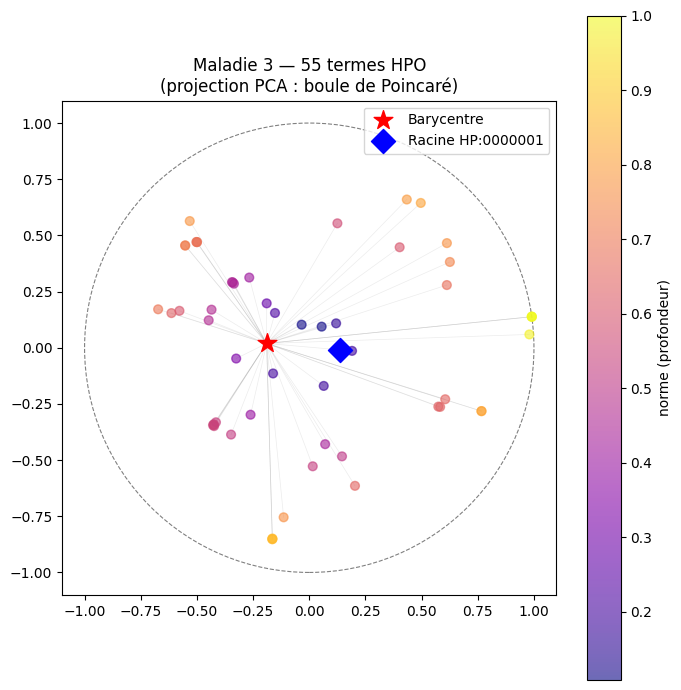

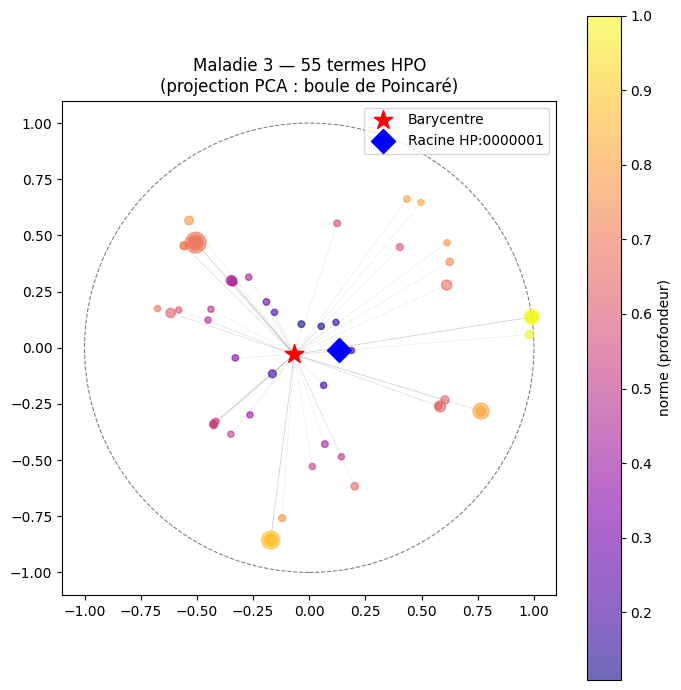

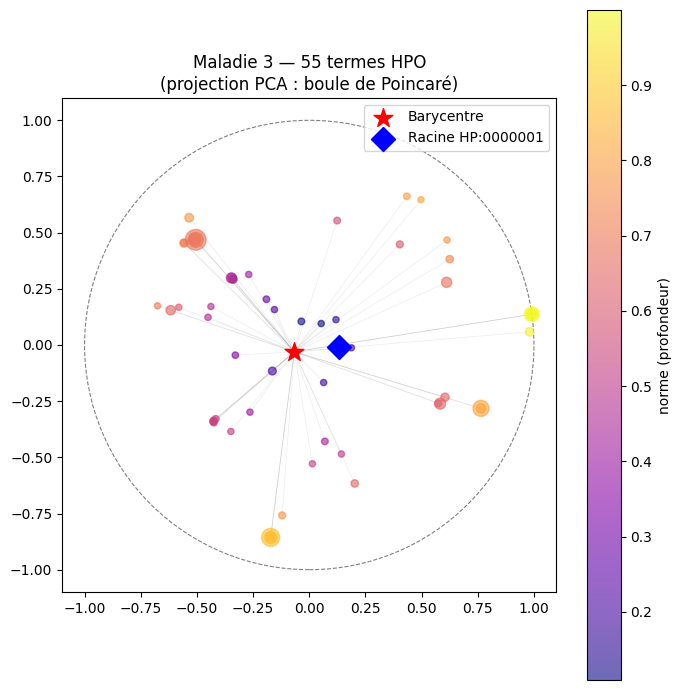

In [ ]:
visualize_barycenter(profils_test,node2id_w, model, deprecated)
visualize_barycenter(profils_test_norm, node2id_w, model, deprecated, weights=inv_weights)
visualize_barycenter(profils_test_weight, node2id_w, model, deprecated, weights=inv_weights)

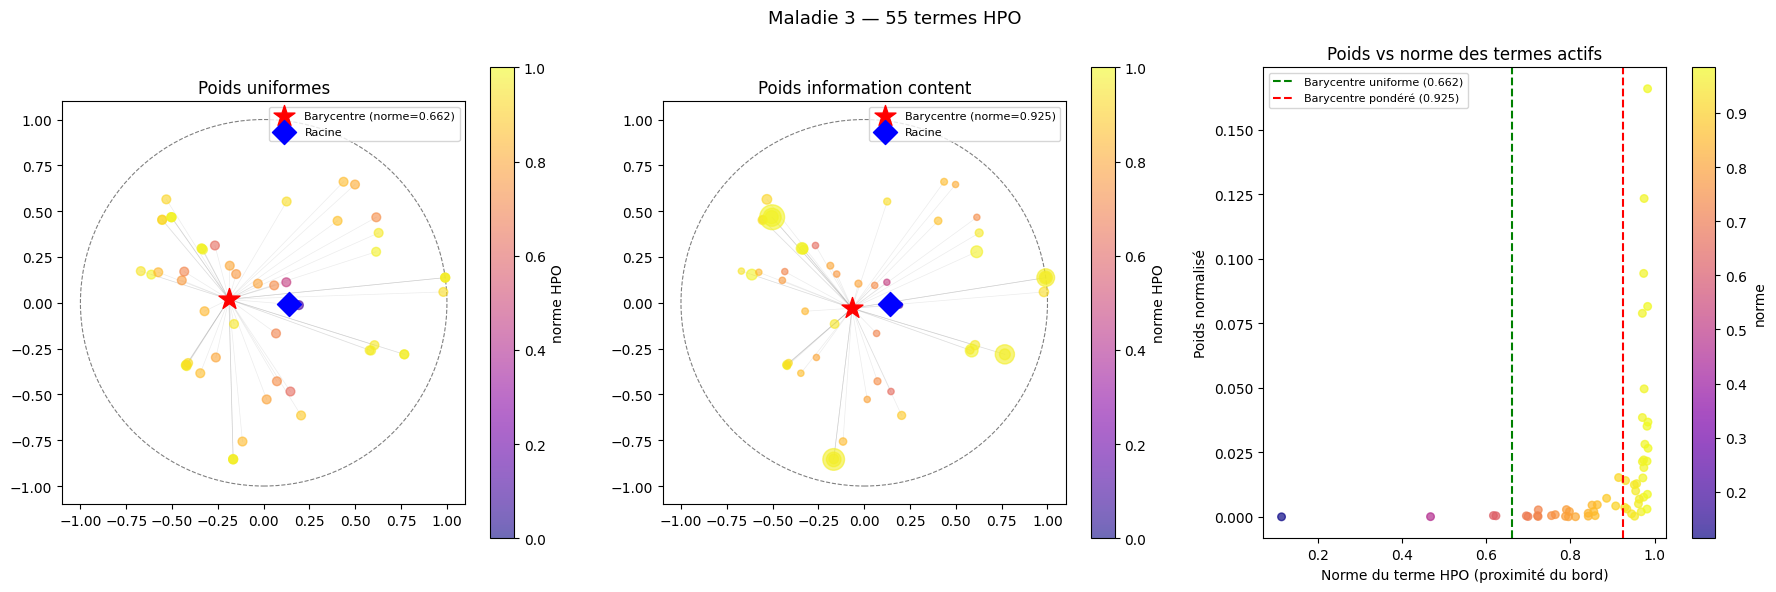

In [ ]:
compare_barycenters(profils_test, profils_test_weight, model, node2id_w, deprecated, inv_weights)

## Chargement des profils ORPHA

On souhaite d'abord vérifier si la représentation via les *embeddings* permet d'obtenir de meilleurs plans de transport qu'auparavant, avec la distance de Jaccard. En particulier, on dispose de deux représentations des maladies : des barycentres pondérés uniformément ou bien pondérés par l'*information content*. On réalise d'abord le transport entre les maladies des bases OMIM et ORPHA. On aimerait que chaque maladie de la première base soit transportée le plus fidèlement sur la maladie correspondante dans la seconde base.

In [10]:
profils_orpha = pd.read_csv("../data/target_orpha_matrix.csv", index_col=0)
profils_orpha = profils_orpha.reset_index()
profils_orpha.head()

/tmp/ipykernel_1749/4227213603.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_orpha = profils_orpha.reset_index()


,database_id,HP:0000002,HP:0000003,HP:0000008,HP:0000009,HP:0000010,HP:0000011,HP:0000012,HP:0000013,HP:0000015,...,HP:6000361,HP:6000572,HP:6000578,HP:6000623,HP:6000642,HP:6000748,HP:6000976,HP:6001074,HP:6001185,gene
0,ORPHA:100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ATM
1,ORPHA:1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AP3D1
2,ORPHA:100006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APP
3,ORPHA:100008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CST3
4,ORPHA:100050,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SERPING1


In [11]:
def read_hpoa(path):
    with open(path, 'r') as f:
        skip = sum(1 for line in f if line.startswith('#'))
    return pd.read_csv(path, sep='\t', skiprows=skip, low_memory=False)

df_hpoa = read_hpoa('../data/phenotype_omim_orpha.hpoa')
df_hpoa['disease_name'] =df_hpoa['disease_name'].str.lower().str.strip().str.replace(r'[\s\-]+', ' ', regex=True)
df_hpoa.tail()

,database_id,disease_name,qualifier,hpo_id,reference,evidence,onset,frequency,sex,modifier,aspect,biocuration
282718,ORPHA:1777,temtamy syndrome,NaN,HP:0000324,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282719,ORPHA:1777,temtamy syndrome,NaN,HP:0000506,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282720,ORPHA:1777,temtamy syndrome,NaN,HP:0000568,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282721,ORPHA:1777,temtamy syndrome,NaN,HP:0004209,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282722,ORPHA:1777,temtamy syndrome,NaN,HP:0001382,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]


In [12]:
# Correspondances OMIM-ORPHA dans hpoa
correspondence_exacte = build_disease_correspondence(df_hpoa)
print(f"Correspondances trouvées : {len(correspondence_exacte)}")
print(f"Nombre de maladies OMIM initial : {profils_omim.shape[0]}")
correspondence_exacte.head()

Correspondances trouvées : 550
Nombre de maladies OMIM initial : 6139


,disease_name,omim_id,orpha_id
0,cerebrocostomandibular syndrome,OMIM:117650,ORPHA:1393
1,retinitis pigmentosa,OMIM:268000,ORPHA:791
2,gitelman syndrome,OMIM:263800,ORPHA:358
3,peters plus syndrome,OMIM:261540,ORPHA:709
4,peutz jeghers syndrome,OMIM:175200,ORPHA:2869


In [13]:
# Correspondances à 95% OMIM-ORPHA dans hpoa
correspondence_95 = build_fuzzy_correspondence(df_hpoa, threshold=0.95)
print(f"Correspondances trouvées : {len(correspondence_95)}")
print(f"Nombre de maladies OMIM initial : {profils_omim.shape[0]}")
correspondence_95.tail()

Correspondances exactes (=1.0)  : 553
Correspondances >= 0.95      : 1209
Correspondances trouvées : 1209
Nombre de maladies OMIM initial : 6139


,omim_id,orpha_id,omim_name,orpha_name,similarity
999,OMIM:207750,ORPHA:425,apolipoprotein c ii deficiency,apolipoprotein a i deficiency,0.9504
208,OMIM:607596,ORPHA:2254,pontocerebellar hypoplasia type 1a,pontocerebellar hypoplasia type 1,0.9504
295,OMIM:617194,ORPHA:1486,lethal congenital contracture syndrome 11,lethal congenital contracture syndrome type 1,0.9504
357,OMIM:606835,ORPHA:85169,"digital arthropathy brachydactyly, familial",familial digital arthropathy brachydactyly,0.9502
1201,OMIM:137200,ORPHA:324442,"neuromyotonia and axonal neuropathy, autosomal...",autosomal recessive axonal neuropathy with neu...,0.9502


#### **Construction de dataframes pour le transport (I)**

In [14]:
# Construction de deux dataframes à partir de df_hpoa
df_pivot = df_hpoa[['database_id', 'hpo_id']].drop_duplicates()
df_pivot['values']=1.
df_pivot = pd.pivot_table(data=df_pivot, values='values', index='database_id', columns='hpo_id', aggfunc='max', fill_value=0)
df_pivot.columns.name = None
df_pivot = df_pivot.reset_index()

df_orpha = df_pivot[df_pivot['database_id'].str.startswith('ORPHA:')]
df_orpha = df_orpha[df_orpha['database_id'].isin(correspondence_exacte['orpha_id'])]

df_omim = df_pivot[df_pivot['database_id'].str.startswith('OMIM:')]
df_omim = df_omim[df_omim['database_id'].isin(correspondence_exacte['omim_id'])]

# Poids associés aux maladies dans ce dataframe là
df_weights, _, _ = compute_information_content(df_omim, G_hpo_work, deprecated)
df_inv_weigths = {t:1/w for t,w in df_weights.items()}

# Barycentres
df_omim = compute_disease_barycenters(df_omim.copy(), node2id_w, deprecated)
df_omim_weights = compute_disease_barycenters(df_omim.copy(), node2id_w, deprecated, df_inv_weigths)

df_orpha = compute_disease_barycenters(df_orpha.copy(), node2id_w, deprecated)
df_orpha_weights = compute_disease_barycenters(df_orpha.copy(), node2id_w, deprecated, df_inv_weigths)

Barycentres: 100%|██████████| 550/550 [00:21<00:00, 25.39it/s]


#### **Construction de dataframes pour le transport (II)**

In [19]:
omim_ids_profils = profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
omim_ids_found = set(correspondence_exacte['omim_id']) & set(omim_ids_profils)
print(f"OMIM IDs dans la correspondance : {len(correspondence_exacte['omim_id'].unique())}")
print(f"OMIM IDs dans profils_omim : {len(omim_ids_profils.dropna().unique())}")
print(f"OMIM IDs en commun : {len(omim_ids_found)}")

orpha_ids = correspondence_exacte.loc[correspondence_exacte['omim_id'].isin(omim_ids_found)]['orpha_id']
orpha_ids_found = set(profils_orpha['database_id'])&set(orpha_ids)

omim_ids_final = correspondence_exacte.loc[correspondence_exacte['orpha_id'].isin(orpha_ids_found)]['omim_id']
print(len(orpha_ids_found))
print(len(omim_ids_final))

OMIM IDs dans la correspondance : 550
OMIM IDs dans profils_omim : 6139
OMIM IDs en commun : 382
307
307


In [20]:
profils_omim['OMIM']= profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_work = profils_omim.loc[profils_omim['OMIM'].isin(omim_ids_final)]
profils_orpha_work = profils_orpha[profils_orpha['database_id'].isin(orpha_ids_found)]
print(profils_orpha_work.shape)
print(profils_omim_work.shape)

/tmp/ipykernel_7950/92326003.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim['OMIM']= profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]


(307, 4897)
(307, 5489)


In [21]:
profils_orpha_test = profils_orpha_work.copy()
profils_orpha_test = compute_disease_barycenters(profils_orpha_test, node2id_w)

profils_orpha_weights = profils_orpha_work.copy()
profils_orpha_weights = compute_disease_barycenters(profils_orpha_weights, node2id_w, deprecated, inv_weights)

profils_test['OMIM'] = profils_test['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_test2 = profils_test.loc[profils_test['OMIM'].isin(omim_ids_final)]

profils_test_weight['OMIM'] = profils_test_weight['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_weight2 = profils_test_weight.loc[profils_test_weight['OMIM'].isin(omim_ids_final)]

Barycentres:   0%|          | 0/307 [00:00<?, ?it/s]

Barycentres: 100%|██████████| 307/307 [00:05<00:00, 58.93it/s]


In [22]:
omim_ids_ordered = profils_omim_test2['OMIM'].values
orpha_ids_ordered = profils_orpha_test['database_id'].values
# Index des maladies
omim_to_idx = {v: i for i, v in enumerate(omim_ids_ordered)} 
orpha_to_idx = {v: i for i, v in enumerate(orpha_ids_ordered)}

ground_truth = []
for _, row in correspondence_exacte.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

gt_set = set(ground_truth)


## Approche 1 : transport entre barycentres avec la distance de Poincaré

In [23]:
costs_test = compute_cost_matrix(profils_omim_test2, profils_orpha_test)
costs_test_weights = compute_cost_matrix(profils_omim_weight2, profils_orpha_weights)

print("========== Costs Test ==========")
print("Moyenne : ", costs_test.mean())
print("Médiane : ", np.median(costs_test))
print("Min : ", costs_test.min())
print("Max : ", costs_test.max())

print("========== Costs Test Weights ==========")
print("Moyenne : ", costs_test_weights.mean())
print("Médiane : ", np.median(costs_test_weights))
print("Min : ", costs_test_weights.min())
print("Max : ", costs_test_weights.max())

========== Costs Test ==========
Moyenne :  2.8253320137243088
Médiane :  2.773041493534468
Min :  0.9253385415240234
Max :  5.8089711514334095
========== Costs Test Weights ==========
Moyenne :  5.917065988785654
Médiane :  5.919185349830598
Min :  1.337122823900508
Max :  8.740098933631268


Text(0.5, 1.0, 'Distances de Poincaré entre maladies : représentations pondérée (orange) et non pondérée(bleu)')

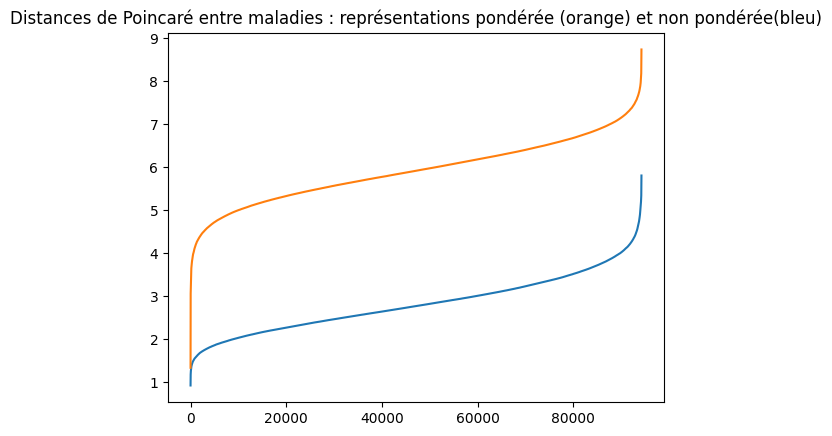

In [27]:
plt.plot(np.sort(costs_test.ravel()))
plt.plot(np.sort(costs_test_weights.ravel()))
plt.title("Distances de Poincaré entre maladies : représentations pondérée (orange) et non pondérée(bleu)")

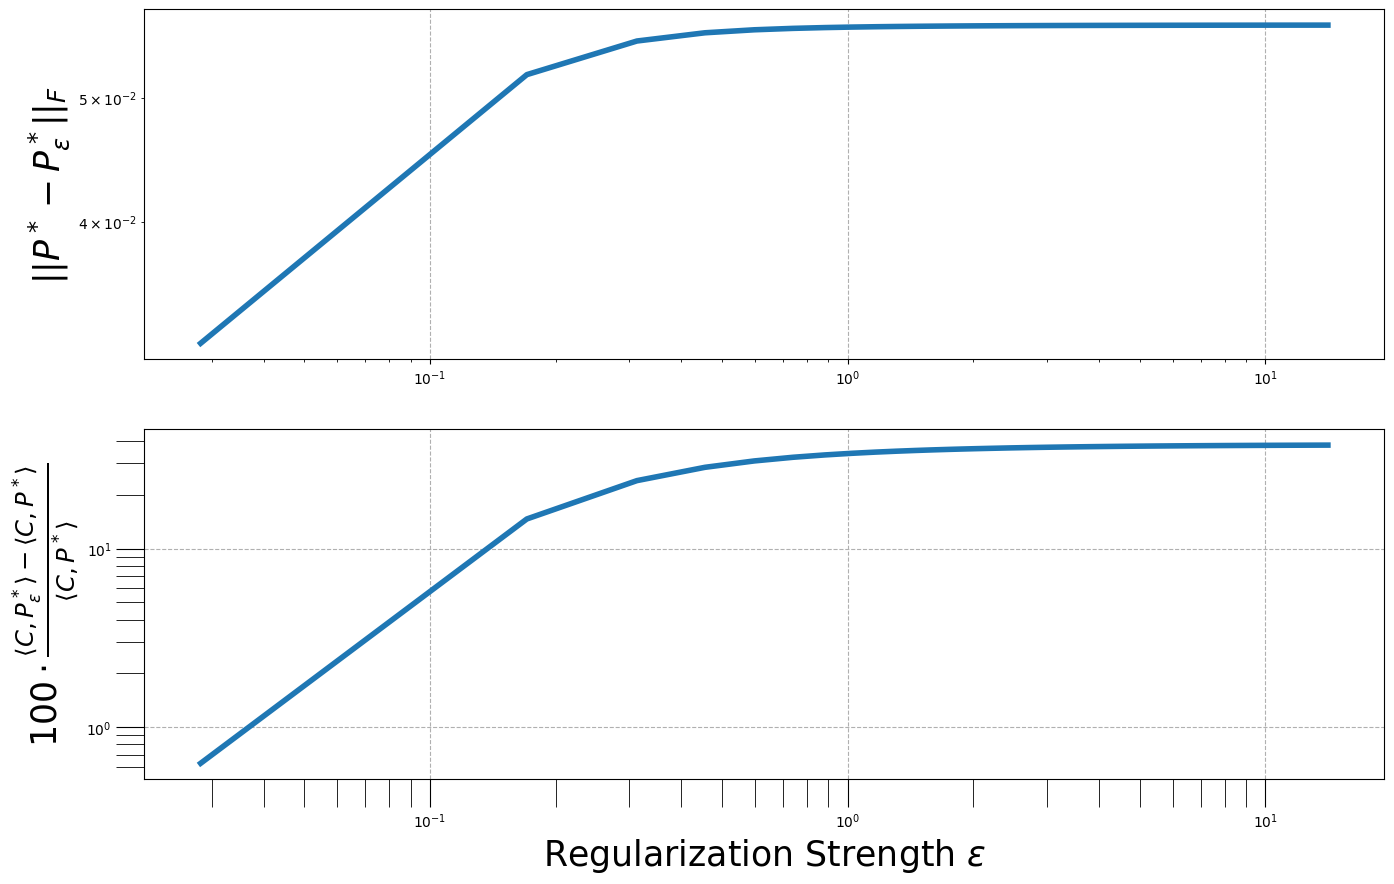

In [ ]:
# Costs test : evolution wrt reg
plan_diff = []
distance_diff = []
grid = np.linspace(0.01, 5, 100)
optimal_plan_sinkhorn, optimal_cost_sinkhorn = compute_transport(costs_test, a=None, b=None)

for epsilon_prime in grid:
  epsilon = epsilon_prime * np.mean(costs_test)
  optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(costs_test, None, None, epsilon, 10000, 1e-4, False)

  assert optimal_cost_sinkhorn_croissant != np.nan, (
      "Optimal cost is nan due to numerical instabilities."
  )
  p = norm(optimal_plan_sinkhorn_croissant - optimal_plan_sinkhorn)
  plan_diff.append(p)
  dist = 100 * (optimal_cost_sinkhorn_croissant - optimal_cost_sinkhorn)/optimal_cost_sinkhorn
  distance_diff.append(dist)


fig, ax = plt.subplots(2, 1, figsize=(16, 5*2))
reg_strengths = np.mean(costs_test) * grid
plot_consistency(
    ax,
    reg_strengths,
    plan_diff,
    distance_diff
)

plt.show()

Prendre $\epsilon'$ entre $0.02$ et $0.1$ semble raisonnable : on conserve une erreur relative environ inférieure à $5\%$

In [ ]:
ranks, pairs = evaluate_transport(optimal_plan_sinkhorn, gt_set, costs_test)

epsilon_prime = grid[5]
epsilon = epsilon_prime * np.mean(costs_test)
print(epsilon_prime, epsilon)
optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(costs_test, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(optimal_plan_sinkhorn_croissant, gt_set, costs_test)

Paires évaluées : 307
Top-1 accuracy : 0.221 (68/307)
Top-3 accuracy : 0.221 (68/307)
Top-5 accuracy : 0.231 (71/307)
 Rang moyen: 124.28


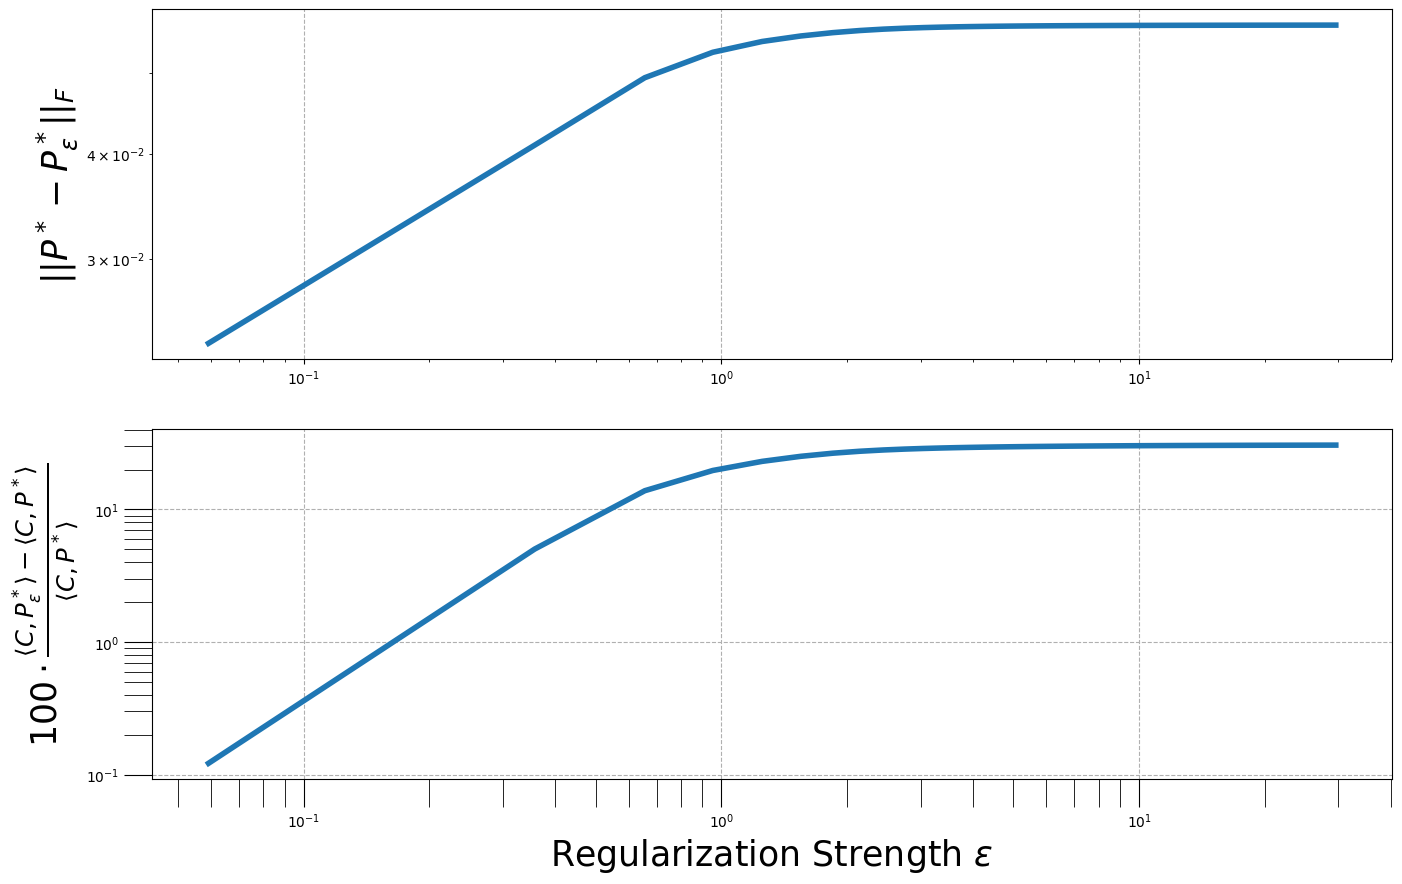

In [32]:
plan_diff = []
distance_diff = []
grid = np.linspace(0.01, 5, 100)
optimal_plan_sinkhorn_weights, optimal_cost_sinkhorn_weights = compute_transport(costs_test_weights, a=None, b=None)

for epsilon_prime in grid:
  epsilon = epsilon_prime * np.mean(costs_test)
  optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(costs_test_weights, None, None, epsilon, 10000, 1e-4, False)

  assert optimal_cost_sinkhorn_croissant != np.nan, (
      "Optimal cost is nan due to numerical instabilities."
  )
  p = norm(optimal_plan_sinkhorn_croissant - optimal_plan_sinkhorn_weights)
  plan_diff.append(p)
  dist = 100 * (optimal_cost_sinkhorn_croissant - optimal_cost_sinkhorn_weights)/optimal_cost_sinkhorn_weights
  distance_diff.append(dist)


fig, ax = plt.subplots(2, 1, figsize=(16, 5*2))
reg_strengths = np.mean(costs_test_weights) * grid
plot_consistency(
    ax,
    reg_strengths,
    plan_diff,
    distance_diff
)

plt.show()

In [33]:
# Transport avec les barycentres pondérés
print("======= Sans régularisation =======")
ranks_w, pairs_w = evaluate_transport(optimal_plan_sinkhorn_weights, gt_set, costs_test_weights)

print("")
print("======= Avec régularisation =======")
epsilon_prime = grid[5]
epsilon = epsilon_prime * np.mean(costs_test_weights)
print(epsilon_prime, epsilon)
optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(costs_test_weights, None, None, epsilon, 10000, 1e-4, False)
ranks_reg_w, pairs_reg_w = evaluate_transport(optimal_plan_sinkhorn_croissant, gt_set, costs_test_weights)

======= Sans régularisation =======
Paires évaluées : 307
Top-1 accuracy : 0.176 (54/307)
Top-3 accuracy : 0.186 (57/307)
Top-5 accuracy : 0.189 (58/307)
 Rang moyen: 127.66

======= Avec régularisation =======
0.26202020202020204 1.5503908257484837
Paires évaluées : 307
Top-1 accuracy : 0.176 (54/307)
Top-3 accuracy : 0.313 (96/307)
Top-5 accuracy : 0.349 (107/307)
 Rang moyen: 65.16


Il faut essayer de comprendre un peu quels sont les maladies qui ont été correctement transportées et celles qui ne l'ont pas été. 

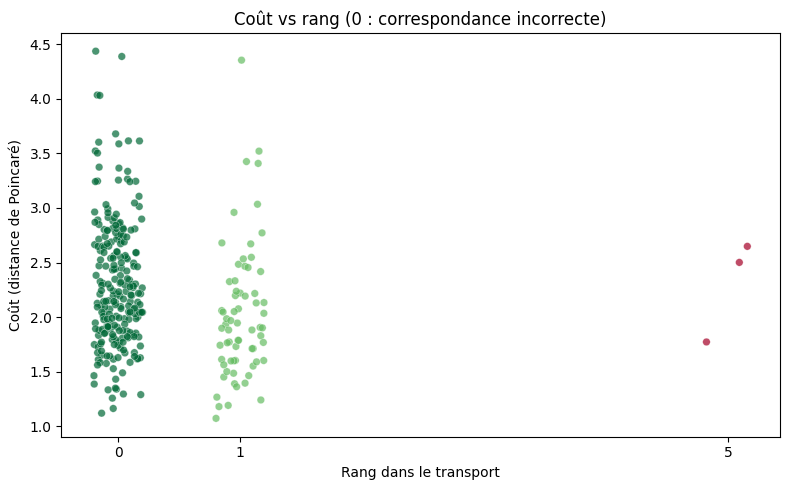

In [67]:
ranks  = np.array([v[0] for v in pairs.values()])
costs  = np.array([v[1] for v in pairs.values()])

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=ranks + np.random.uniform(-0.2, 0.2, size=len(ranks)),  # jitter pour lisibilité
    y=costs,
    c=ranks,
    cmap='RdYlGn_r',
    s=30,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)

ax.set_xlabel('Rang dans le transport')
ax.set_ylabel('Coût (distance de Poincaré)')
ax.set_title('Coût vs rang (0 : correspondance incorrecte)')
ax.set_xticks(sorted(set(ranks)))
plt.tight_layout()
plt.show()

In [15]:
# Avec df_omim et df_orpha issus directement de df_hpoa
omim_to_idx = {v: i for i, v in enumerate(df_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(df_orpha['database_id'].values)}

ground_truth = []
for _, row in correspondence_exacte.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

df_gt_set = set(ground_truth)

In [16]:
print("======== Sans régularisation ========")
C = compute_cost_matrix(df_omim, df_orpha)
df_ot_plan, df_ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(df_ot_plan, df_gt_set, C)

C_weigths = compute_cost_matrix(df_omim_weights, df_orpha_weights)
df_ot_plan_w, df_ot_cost_w = compute_transport(C_weigths, a=None, b=None)
ranks_w, pairs_w = evaluate_transport(df_ot_plan_w, df_gt_set, C_weigths)

print("======== Avec régularisation ========")
epsilon = 0.1*np.mean(C)
df_ot_plan_reg, df_or_cost_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_r, pairs_r = evaluate_transport(df_ot_plan_reg, df_gt_set, C)

epsilon_w = 0.1*np.mean(C_weigths)
df_ot_plan_reg_w, df_ot_cost_reg_w = compute_transport_sinkhorn(C_weigths, None, None, epsilon_w, 10000, 1e-4, False)
ranks_rw, pairs_rw = evaluate_transport(df_ot_plan_reg_w, df_gt_set, C_weigths)

======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.220 (121/550)
Top-3 accuracy : 0.224 (123/550)
Top-5 accuracy : 0.225 (124/550)
 Rang moyen: 214.73
Paires évaluées : 550
Top-1 accuracy : 0.182 (100/550)
Top-3 accuracy : 0.185 (102/550)
Top-5 accuracy : 0.189 (104/550)
 Rang moyen: 224.47
======== Avec régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.231 (127/550)
Top-3 accuracy : 0.378 (208/550)
Top-5 accuracy : 0.455 (250/550)
 Rang moyen: 36.15
Paires évaluées : 550
Top-1 accuracy : 0.195 (107/550)
Top-3 accuracy : 0.289 (159/550)
Top-5 accuracy : 0.336 (185/550)
 Rang moyen: 78.80


### Approche 1 (bis)

On essaye de calculer la matrice de coût pour le transport d'une manière différente, se rapprochant davantage de la distance de Jaccard. Plutôt que de considérer la distance de Poincaré entre les barycentres de deux maladies $M_1$, $M_2$, on calcule : 
$$d(M_1, M_2)=\sum_i |\mathbb{1}_{HPO_i\in M_1}-\mathbb{1}_{HPO_i\in M_2}|\times \lVert w_{HPO_i}\rVert_\mathbb{P}^2 $$

In [18]:
C_jacc = compute_cost_matrix_pseudo_jacc(df_omim, df_orpha, node2id_w, model)

print("========== Costs ==========")
print("Moyenne : ", C_jacc.mean())
print("Médiane : ", np.median(C_jacc))
print("Min : ", C_jacc.min())
print("Max : ", C_jacc.max())

Compute norms


Norms computed !
['HP:0000002', 'HP:0000003', 'HP:0000006', 'HP:0000007', 'HP:0000008', 'HP:0000009', 'HP:0000010', 'HP:0000011', 'HP:0000012', 'HP:0000013', 'HP:0000014', 'HP:0000015', 'HP:0000016', 'HP:0000017', 'HP:0000019', 'HP:0000020', 'HP:0000021', 'HP:0000022', 'HP:0000023', 'HP:0000024', 'HP:0000025', 'HP:0000026', 'HP:0000027', 'HP:0000028', 'HP:0000029', 'HP:0000030', 'HP:0000031', 'HP:0000032', 'HP:0000033', 'HP:0000034', 'HP:0000035', 'HP:0000036', 'HP:0000037', 'HP:0000039', 'HP:0000040', 'HP:0000041', 'HP:0000042', 'HP:0000044', 'HP:0000045', 'HP:0000046', 'HP:0000047', 'HP:0000048', 'HP:0000049', 'HP:0000050', 'HP:0000051', 'HP:0000052', 'HP:0000053', 'HP:0000054', 'HP:0000055', 'HP:0000056', 'HP:0000058', 'HP:0000059', 'HP:0000060', 'HP:0000061', 'HP:0000062', 'HP:0000063', 'HP:0000064', 'HP:0000065', 'HP:0000066', 'HP:0000068', 'HP:0000069', 'HP:0000070', 'HP:0000071', 'HP:0000072', 'HP:0000073', 'HP:0000074', 'HP:0000075', 'HP:0000076', 'HP:0000077', 'HP:0000078', 'H

100%|██████████| 3/3 [00:44<00:00, 14.83s/it]


C[0,0]  ref=198.891600  new=198.891600  diff=5.68e-14
C[3,7]  ref=368.206632  new=368.206632  diff=5.68e-14
C[9,14]  ref=233.015199  new=233.015199  diff=2.84e-14
========== Costs ==========
Moyenne :  239.76371580930632
Médiane :  219.70573791804082
Min :  11.568850110603705
Max :  1110.6627141502372


Paires évaluées : 550
Top-1 accuracy : 0.820 (451/550)
Top-3 accuracy : 0.822 (452/550)
Top-5 accuracy : 0.822 (452/550)
 Rang moyen: 49.69


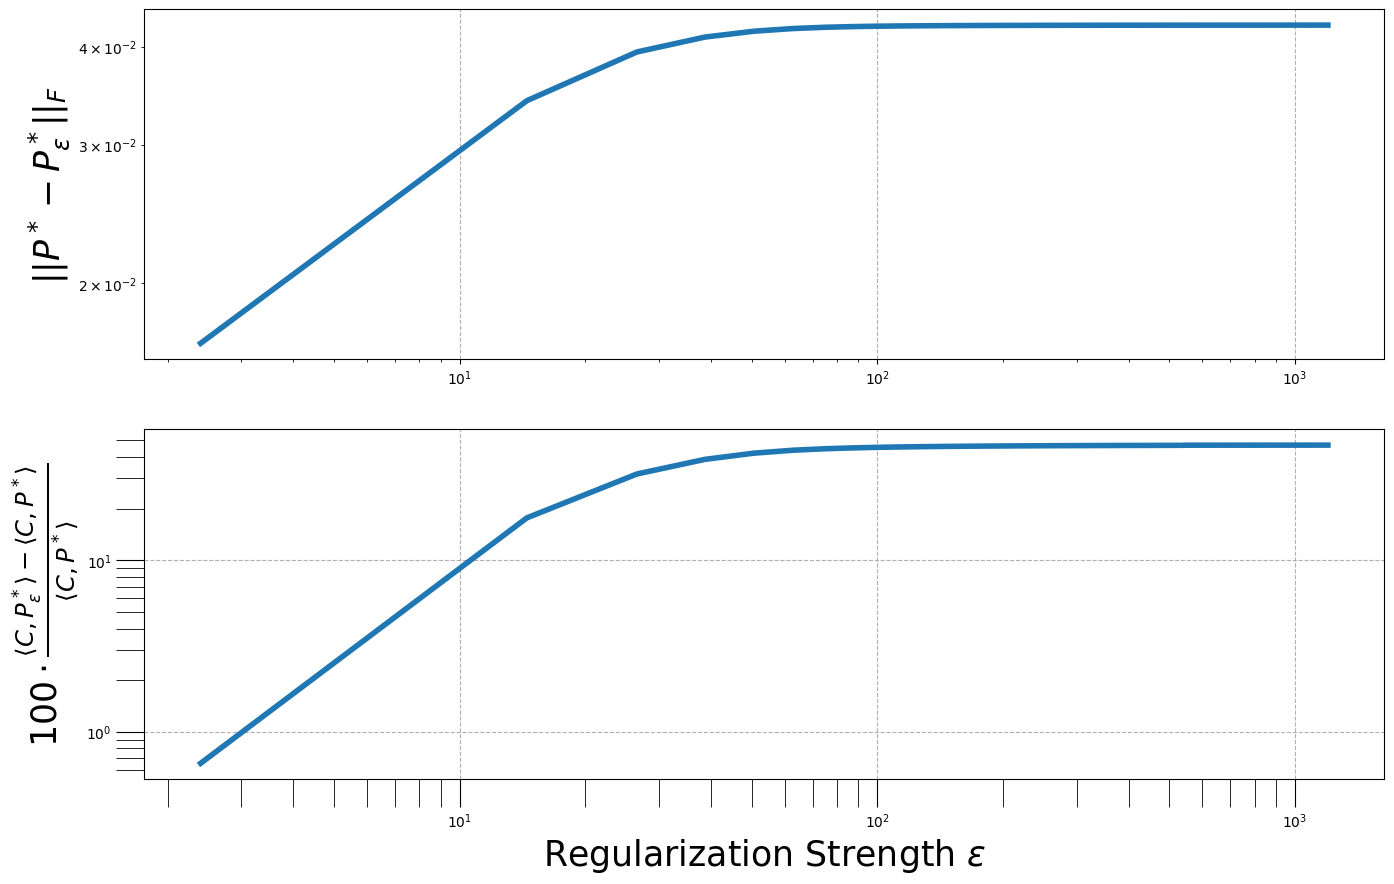

In [19]:
# Transport sans régularisation
jacc_ot_plan, jacc_ot_cost = compute_transport(C_jacc, a=None, b=None)
ranks, pairs = evaluate_transport(jacc_ot_plan, df_gt_set, C_jacc)

# Transport avec régularisation
plan_diff = []
distance_diff = []
grid = np.linspace(0.01, 5, 100)

for epsilon_prime in grid:
  epsilon = epsilon_prime * np.mean(C_jacc)
  optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(C_jacc, None, None, epsilon, 10000, 1e-4, False)

  assert optimal_cost_sinkhorn_croissant != np.nan, (
      "Optimal cost is nan due to numerical instabilities."
  )
  p = norm(optimal_plan_sinkhorn_croissant - jacc_ot_plan)
  plan_diff.append(p)
  dist = 100 * (optimal_cost_sinkhorn_croissant - jacc_ot_cost)/jacc_ot_cost
  distance_diff.append(dist)


fig, ax = plt.subplots(2, 1, figsize=(16, 5*2))
reg_strengths = np.mean(C_jacc) * grid
plot_consistency(
    ax,
    reg_strengths,
    plan_diff,
    distance_diff
)

plt.show()


In [20]:
print("======== Avec régularisation ========")
epsilon = grid[0]*np.mean(C_jacc)
print("Régularisation : ", epsilon)
jacc_ot_plan_reg, jacc_or_cost_reg = compute_transport_sinkhorn(C_jacc, None, None, epsilon, 10000, 1e-4, False)
ranks_r, pairs_r = evaluate_transport(jacc_ot_plan_reg, df_gt_set, C_jacc)

======== Avec régularisation ========
Régularisation :  2.397637158093063
Paires évaluées : 550
Top-1 accuracy : 0.835 (459/550)
Top-3 accuracy : 0.898 (494/550)
Top-5 accuracy : 0.907 (499/550)
 Rang moyen: 6.01


Ca marche bien mieux, reste à comprendre pourquoi.

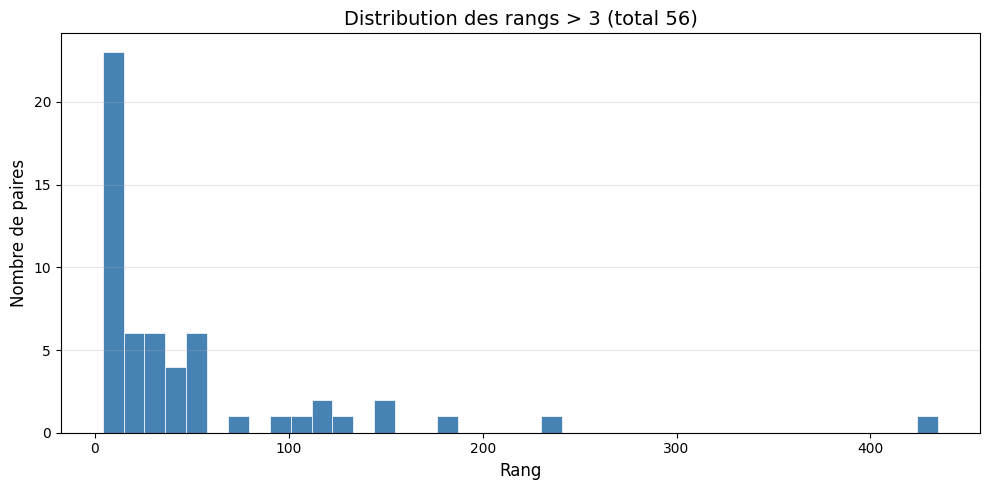

In [21]:
ranks_r = np.array(ranks_r)
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(ranks_r[ranks_r > 3],
        bins=len(np.unique(ranks_r[ranks_r > 3])),
        color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel("Rang", fontsize=12)
ax.set_ylabel("Nombre de paires", fontsize=12)
ax.set_title(f"Distribution des rangs > 3 (total {len(ranks_r[ranks_r > 3])})", fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
dict_ranks_r = {}
for i, k in enumerate(pairs_r.keys()):
    dict_ranks_r[k]=ranks_r[i]

paires_zero = [k for k, v in pairs_r.items() if (v[0] > 3 or v[0]==0)]
paires_zero_dict = {}
hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}
for (i,j) in  paires_zero:
    omim_row  = df_omim.iloc[i][hpo_cols]
    orpha_row = df_orpha.iloc[j][hpo_cols]
    
    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "rank": dict_ranks_r[(i,j)],
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos)
    }

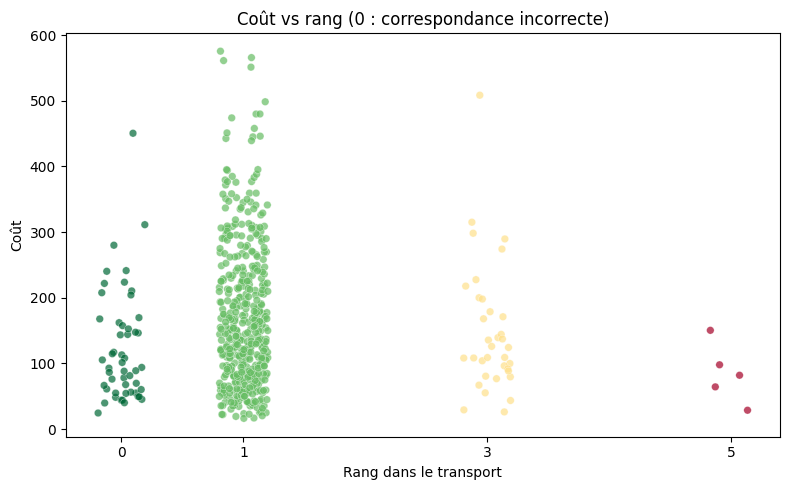

In [23]:
ranks = np.array([v[0] for v in pairs_r.values()])
costs = np.array([v[1] for v in pairs_r.values()])

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=ranks + np.random.uniform(-0.2, 0.2, size=len(ranks)),  # jitter pour lisibilité
    y=costs,
    c=ranks,
    cmap='RdYlGn_r',
    s=30,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)

ax.set_xlabel('Rang dans le transport')
ax.set_ylabel('Coût')
ax.set_title('Coût vs rang (0 : correspondance incorrecte)')
ax.set_xticks(sorted(set(ranks)))
plt.tight_layout()
plt.show()

#### **Cas particulier**

*Ghosal hematodiaphyseal dysplasia syndrome (GHDD) is a rare disorder characterized by increased bone density (predominantly diaphyseal) and aregenerative corticosteroid-sensitive anemia.*

In [24]:
# Cas particulier : ghosal hematodiaphyseal dysplasia (rank=23)
ranked_cols_233 = np.argsort(jacc_ot_plan_reg[233])[::-1]
omim_row_233 = df_omim.iloc[233][hpo_cols]
omim_hpos_233 = omim_row_233[omim_row_233 == 1].index.tolist()
print(idx2omim[233])
print("======== 10 premières maladies associées =======")
for i in range(30):
    ind = ranked_cols_233[i]
    orpha_row_i = df_orpha.iloc[ind][hpo_cols]
    orpha_hpos_i = orpha_row_i[orpha_row_i == 1].index.tolist()
    print(pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[ind]]['disease_name'])[0])
    print("Termes communs : ", set(omim_hpos_233)&set(orpha_hpos_i))
    print("")

OMIM:231095
======== 10 premières maladies associées =======
felty syndrome
Termes communs :  {'HP:0005528', 'HP:0001873'}

paroxysmal nocturnal hemoglobinuria
Termes communs :  {'HP:0001873', 'HP:0001882'}

beta thalassemia
Termes communs :  {'HP:0001873'}

cyclic neutropenia
Termes communs :  {'HP:0001873'}

osteomesopyknosis
Termes communs :  {'HP:0011001'}

gray platelet syndrome
Termes communs :  {'HP:0001873'}

pentosuria
Termes communs :  set()

acropectoral syndrome
Termes communs :  set()

paroxysmal extreme pain disorder
Termes communs :  set()

metachondromatosis
Termes communs :  set()

hemophilia a
Termes communs :  set()

ichthyosis prematurity syndrome
Termes communs :  set()

laryngeal abductor paralysis
Termes communs :  set()

burkitt lymphoma
Termes communs :  set()

coats disease
Termes communs :  set()

palmoplantar keratoderma, nagashima type
Termes communs :  set()

gonadoblastoma
Termes communs :  set()

eosinophilic fasciitis
Termes communs :  set()

pyknoachon

## Statistiques descriptives

Il s'agit de comprendre pourquoi certaines maladies sont correctement transportées et d'autres non et pourquoi avec une distance de type Hamming, le transport permet de retrouver la quasi totalité des correspondances tandis que ça n'est pas le cas en utilisant la distance de Poincaré entre maladies dans la boule.<br>

In [25]:
# Termes actifs
df_omim['active terms']=df_omim.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))
df_orpha["active terms"]=df_orpha.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))

In [26]:
# Termes en commun
common_terms = {}
for (i, j) in df_gt_set:
    omim_terms = set(df_omim.iloc[i][hpo_cols][df_omim.iloc[i][hpo_cols] == 1].index)
    orpha_terms = set(df_orpha.iloc[j][hpo_cols][df_orpha.iloc[j][hpo_cols] == 1].index)
    common_terms[(i, j)] = omim_terms & orpha_terms

omim_common_terms = {i: list(terms) for (i, j), terms in common_terms.items()}
omim_common_count = {i: len(terms) for (i, j), terms in common_terms.items()}

df_omim['gt_common_terms'] = [omim_common_terms.get(i, None) for i in range(len(df_omim))]
df_omim['gt_common_count'] = [omim_common_count.get(i, 0) for i in range(len(df_omim))]

orpha_common_terms = {j: list(terms) for (i, j), terms in common_terms.items()}
orpha_common_count = {j: len(terms) for (i, j), terms in common_terms.items()}

df_orpha['gt_common_terms'] = [orpha_common_terms.get(j, None) for j in range(len(df_orpha))]
df_orpha['gt_common_count'] = [orpha_common_count.get(j, 0) for j in range(len(df_orpha))]

gt_omim2orpha = {i: j for (i, j) in df_gt_set}
gt_orpha2omim = {j: i for (i, j) in df_gt_set}

df_omim['disease_id'] = [idx2orpha.get(gt_omim2orpha.get(i), None)  for i in range(len(df_omim))]
df_orpha['disease_id'] = [idx2omim.get(gt_orpha2omim.get(j), None) for j in range(len(df_orpha))]

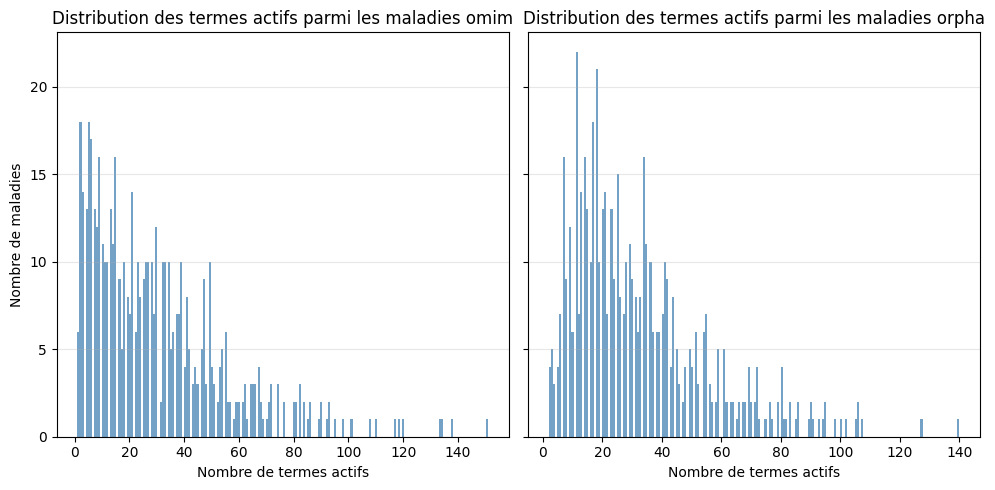

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax = axes[0]
sns.histplot(df_omim["active terms"], bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Distribution des termes actifs parmi les maladies omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(df_orpha["active terms"], bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Distribution des termes actifs parmi les maladies orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

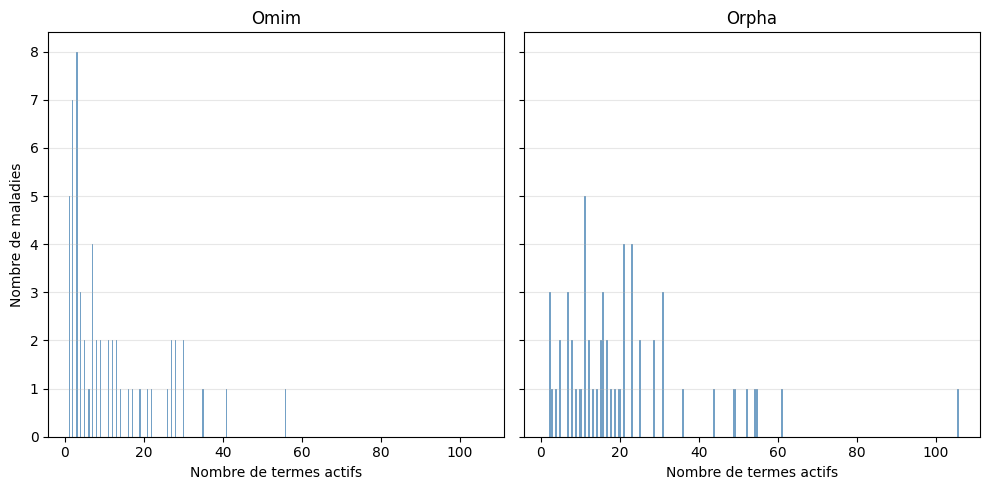

In [28]:
# Nombre de termes omim dans les maladies que l'on ne retrouve pas
omim_counts = np.array([v['omim']['count']  for v in paires_zero_dict.values()])
orpha_counts = np.array([v['orpha']['count'] for v in paires_zero_dict.values()])


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(omim_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(orpha_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

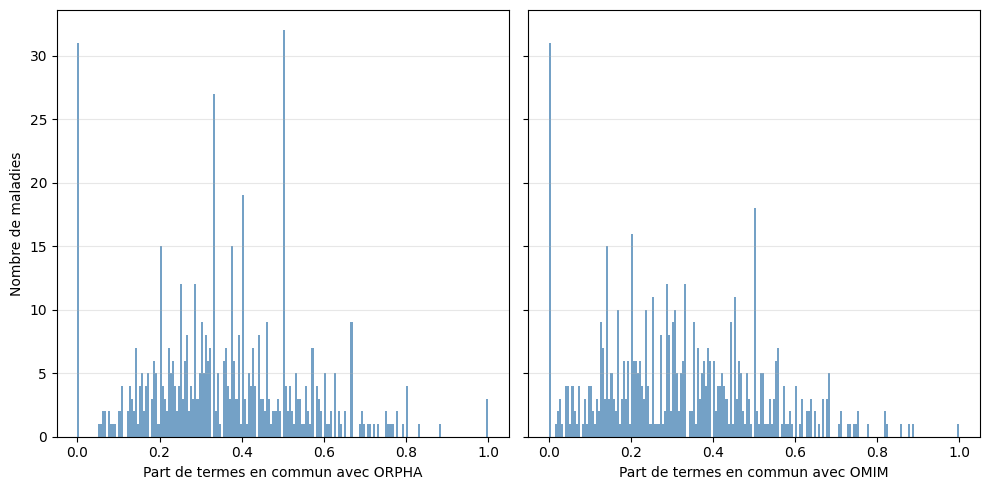

In [39]:
# Termes partagés 
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax = axes[0]
sns.histplot(df_omim["gt_common_count"]/df_omim["active terms"], bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes en commun avec ORPHA")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(df_orpha["gt_common_count"]/df_orpha["active terms"], bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes en commun avec OMIM")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

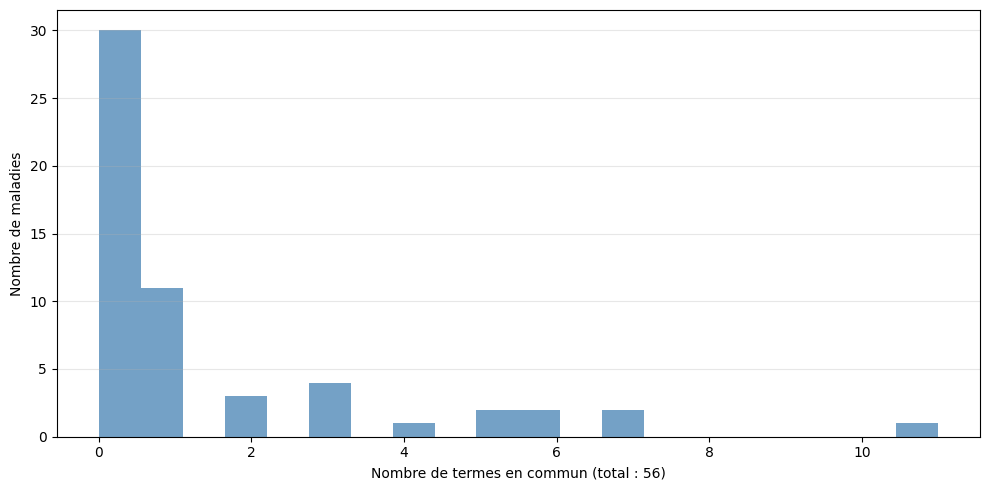

In [40]:
# Termes en commun parmi les maladies non associées
communs = np.array([len(v['commun'])  for v in paires_zero_dict.values()])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(communs, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes en commun (total : {len(communs)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Déjà les maladies sans aucun termes HPO en communs sont, à l'exception d'une, toutes parmi les maladies mal identifiées par le transport.

Il faut voir ce que l'on obtient en ajoutant la régularisation Laplacienne.

## Approche 2 : transport entre maladies avec la distance de Wasserstein

Plutôt que de représenter les maladies comme les barycentres de leurs termes HPO actifs dans la boule de Poincaré, il est possible de les voir comme les distributions empiriques :
$$M = \sum_i \alpha_i^{(M)} \delta_{HPO_i} $$

où $\sum_i \alpha_i^{(M)}=1$, $\alpha_i^{(M)}>0$ si le terme $HPO_i$ est actif pour la maladie $M$ et est nul sinon. 
 
On adopte dans un premier temps une pondération uniforme pour toute les maladies. De même que pour le calcule des barycentres, on peut aussi envisager de pondérer par l'inverse de l'*information content*.
 
Le calcul du coût de transport entre deux maladies $M_1$ et $M_2$ correspond à la distance de Wasserstein $W_2(M_1, M_2)$ entre les deux distributions empiriques dans la boule de Poincaré.

In [29]:
def cost_hpos(hpoi, hpoj):
    Ei = torch.tensor(hpoi, dtype=torch.float64).unsqueeze(1)
    Ej = torch.tensor(hpoj, dtype=torch.float64).unsqueeze(0)
    manifold = PoincareManifold()
    dists = manifold.distance(Ei, Ej, c=1)
    return dists.detach().numpy()


In [ ]:
# VERSION LENTE
def compute_costs_matrix_wasserstein(df_omim, df_orpha, node2id_w, deprecated):
    n=len(df_omim)
    m=len(df_orpha)
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    model.eval()
    W = model.weight.detach().cpu().numpy()
    print("Precompute...")
    def precompute(df):
        terms, weights = [], []
        for _, row in df.iterrows():
            active = f_active_terms(row, hpo_cols, node2id_w, deprecated)
            terms.append(active)
            weights.append(np.ones(len(active)) / len(active) if active else np.array([]))
        return terms, weights
    print("Finished !")
    terms_i, weights_i = precompute(df_omim)
    terms_j, weights_j = precompute(df_orpha)

    all_terms = list({h for ts in terms_i + terms_j for h in ts})
    term2idx  = {h: k for k, h in enumerate(all_terms)}
    E = W[[node2id_w[h] for h in all_terms]]

    idx_i = [[term2idx[h] for h in ts] for ts in terms_i]
    idx_j = [[term2idx[h] for h in ts] for ts in terms_j]

    C=np.zeros((n,m))
    for i, (_, row_i) in enumerate(tqdm(df_omim.iterrows(), total=n, desc="OMIM")):
        active_i = terms_i[i]
        a_i = weights_i[i]
        for j, (_, row_j) in enumerate(df_orpha.iterrows()):
            active_j = terms_j[j]
            b_j = weights_j[j]
            cost_ij = cost_hpos(E[idx_i[i]], E[idx_j[j]])
            _, ot_cost_ij = compute_transport(cost_ij, a_i, b_j)
            C[i,j]=ot_cost_ij
    return C
    

In [30]:
from joblib import Parallel, delayed
def compute_costs_matrix_wasserstein2(df_omim, df_orpha, node2id_w, deprecated):
    n=len(df_omim)
    m=len(df_orpha)
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    model.eval()
    W = model.weight.detach().cpu().numpy()
    print("Precompute...")
    def precompute(df):
        terms, weights = [], []
        for _, row in df.iterrows():
            active = f_active_terms(row, hpo_cols, node2id_w, deprecated)
            terms.append(active)
            weights.append(np.ones(len(active)) / len(active) if active else np.array([]))
        return terms, weights
    print("Finished !")
    terms_i, weights_i = precompute(df_omim)
    terms_j, weights_j = precompute(df_orpha)

    all_terms = list({h for ts in terms_i + terms_j for h in ts})
    term2idx  = {h: k for k, h in enumerate(all_terms)}
    E = W[[node2id_w[h] for h in all_terms]]

    idx_i = [[term2idx[h] for h in ts] for ts in terms_i]
    idx_j = [[term2idx[h] for h in ts] for ts in terms_j]

    C=np.zeros((n,m))
    def compute_row(i):
        if not idx_i[i]:
            return i, np.zeros(len(terms_j))
        Ei = E[idx_i[i]]
        row = np.zeros(len(terms_j))
        for j in range(len(terms_j)):
            if not idx_j[j]:
                continue
            Ej = E[idx_j[j]]
            M  = cost_hpos(Ei, Ej) 
            _, row[j] = compute_transport(M, weights_i[i], weights_j[j])
        return i, row

    results = Parallel(n_jobs=-1)(
        delayed(compute_row)(i) for i in tqdm(range(len(df_omim)), desc="OMIM")
    )
    C = np.zeros((len(df_omim), len(df_orpha)))
    for i, row in results:
        C[i] = row
    return C

cost_wasserstein = compute_costs_matrix_wasserstein2(df_omim, df_orpha, node2id_w, deprecated)

print("========== Costs ==========")
print("Moyenne : ", cost_wasserstein.mean())
print("Médiane : ", np.median(cost_wasserstein))
print("Min : ", cost_wasserstein.min())
print("Max : ", cost_wasserstein.max())

Precompute...
Finished !


OMIM: 100%|██████████| 550/550 [00:26<00:00, 20.96it/s]


========== Costs ==========
Moyenne :  6.588784647599613
Médiane :  6.645715958872975
Min :  1.1566428884940658
Max :  8.817021158009407


Paires évaluées : 550
Top-1 accuracy : 0.820 (451/550)
Top-3 accuracy : 0.822 (452/550)
Top-5 accuracy : 0.822 (452/550)
 Rang moyen: 50.86


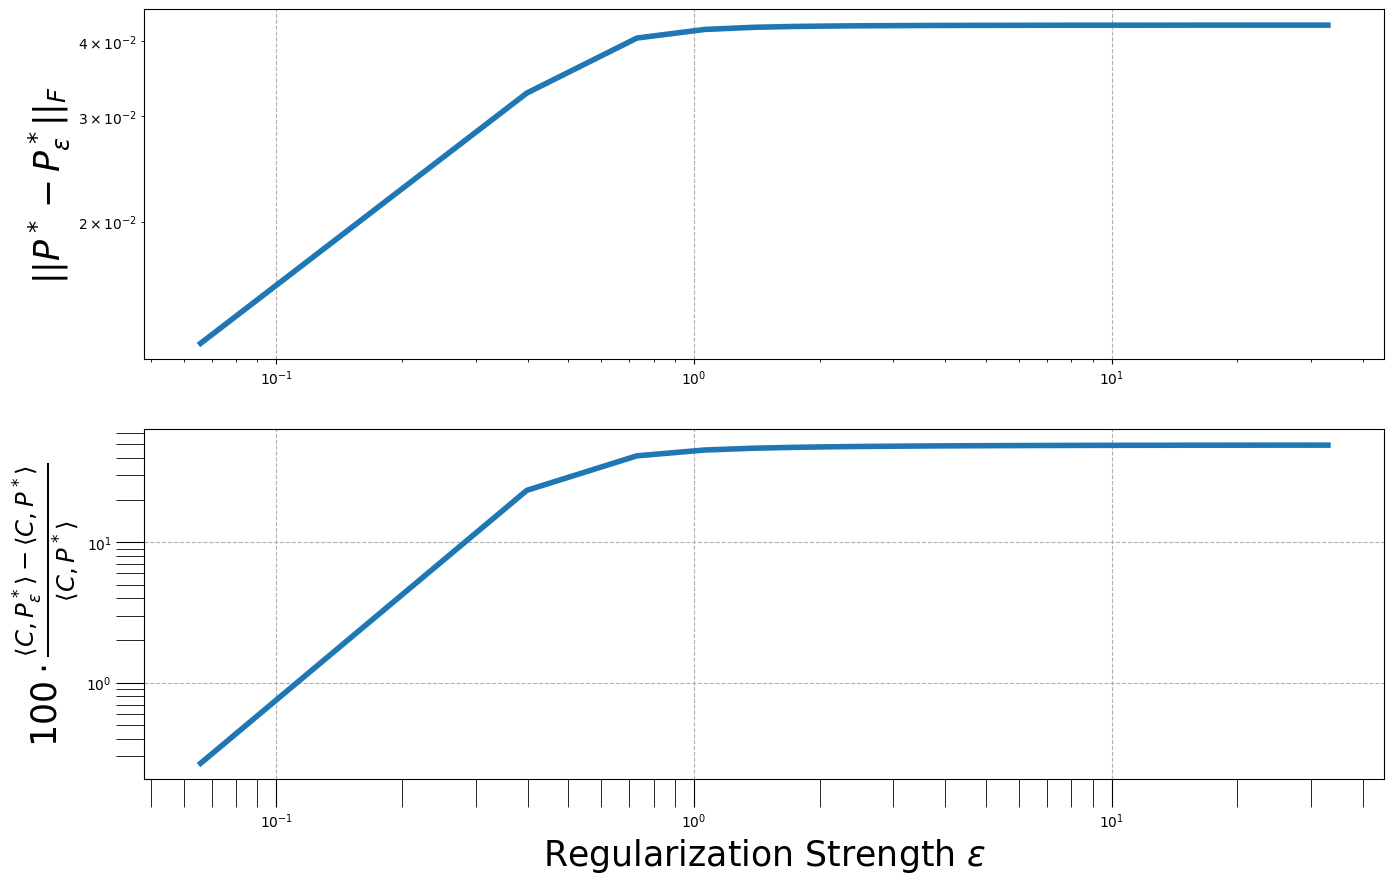

In [31]:
# Transport sans régularisation
wass_ot_plan, wass_ot_cost = compute_transport(cost_wasserstein, a=None, b=None)
ranks, pairs = evaluate_transport(wass_ot_plan, df_gt_set, cost_wasserstein)

# Transport avec régularisation
plan_diff = []
distance_diff = []
grid = np.linspace(0.01, 5, 100)

for epsilon_prime in grid:
  epsilon = epsilon_prime * np.mean(cost_wasserstein)
  optimal_plan_sinkhorn_croissant, optimal_cost_sinkhorn_croissant = compute_transport_sinkhorn(cost_wasserstein, None, None, epsilon, 10000, 1e-4, False)

  assert optimal_cost_sinkhorn_croissant != np.nan, (
      "Optimal cost is nan due to numerical instabilities."
  )
  p = norm(optimal_plan_sinkhorn_croissant - wass_ot_plan)
  plan_diff.append(p)
  dist = 100 * (optimal_cost_sinkhorn_croissant - wass_ot_cost)/wass_ot_cost
  distance_diff.append(dist)


fig, ax = plt.subplots(2, 1, figsize=(16, 5*2))
reg_strengths = np.mean(cost_wasserstein) * grid
plot_consistency(
    ax,
    reg_strengths,
    plan_diff,
    distance_diff
)

plt.show()


In [32]:
print("======== Avec régularisation ========")
epsilon = grid[0]*np.mean(cost_wasserstein)
#epsilon = 0.01
print("Régularisation : ", epsilon)
wass_ot_plan_reg, wass_or_cost_reg = compute_transport_sinkhorn(cost_wasserstein, None, None, epsilon, 10000, 1e-4, False)
ranks_r, pairs_r = evaluate_transport(wass_ot_plan_reg, df_gt_set, cost_wasserstein)

======== Avec régularisation ========
Régularisation :  0.06588784647599613
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.916 (504/550)
Top-5 accuracy : 0.929 (511/550)
 Rang moyen: 4.29


In [37]:
dict_ranks_w = {}
for i, k in enumerate(pairs_r.keys()):
    dict_ranks_w[k]=ranks_r[i]

paires_zero_w = [k for k, v in pairs_r.items() if (v[0] > 3 or v[0]==0)]
paires_zero_dict_w = {}
hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}
for (i,j) in  paires_zero_w:
    j_pred = np.argmax(wass_ot_plan_reg[i])
    omim_row  = df_omim.iloc[i][hpo_cols]
    orpha_row = df_orpha.iloc[j][hpo_cols]
    orpha_row_pred = df_orpha.iloc[j_pred][hpo_cols]
    
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    orpha_pred_hpos = orpha_row_pred[orpha_row_pred==1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict_w[(i, j)] = {
        "rank": dict_ranks_w[(i,j)],
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
        "cost_true": cost_wasserstein[i, j],
        "cost_pred": cost_wasserstein[i, j_pred],
        "predicted_disease" : pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j_pred]]['disease_name'])[0],
        "count_pred" : len(orpha_pred_hpos),
        "terms pred" : orpha_pred_hpos
    }
print("Paires mal transportées communes aux deux méthodes :")
print(set(paires_zero)&set(paires_zero_w))
print(f"{len(set(paires_zero)&set(paires_zero_w))}/{len(paires_zero_w)} paires")

Paires mal transportées communes aux deux méthodes :
{(212, 13), (69, 321), (541, 48), (110, 337), (94, 271), (245, 455), (357, 364), (346, 245), (354, 490), (528, 142), (43, 94), (371, 73), (79, 212), (253, 279), (393, 491), (20, 379), (339, 74), (456, 488), (310, 236), (17, 20), (356, 489), (362, 493), (448, 468), (45, 453), (532, 40), (511, 368)}
26/46 paires


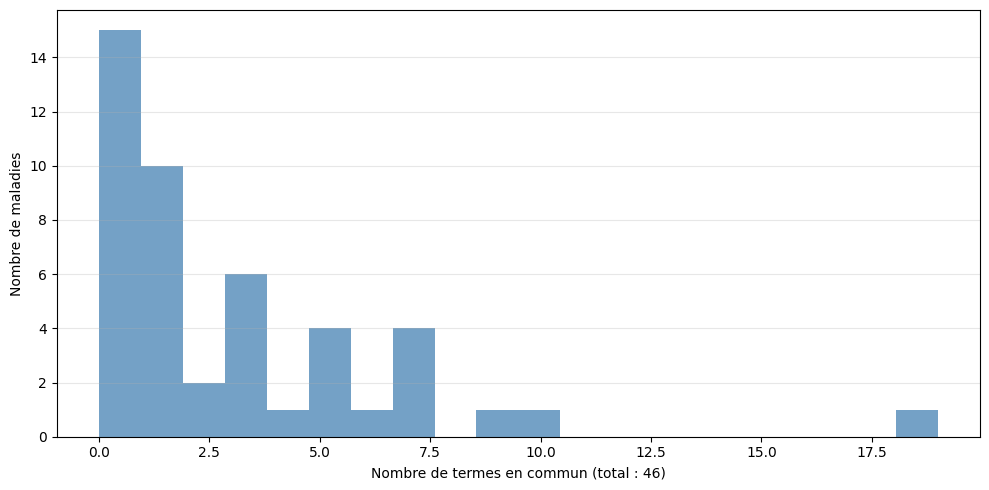

In [34]:
# Termes HP en commun parmi les maladies non associées
communs_w = np.array([len(v['commun'])  for v in paires_zero_dict_w.values()])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(communs_w, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes en commun (total : {len(communs_w)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

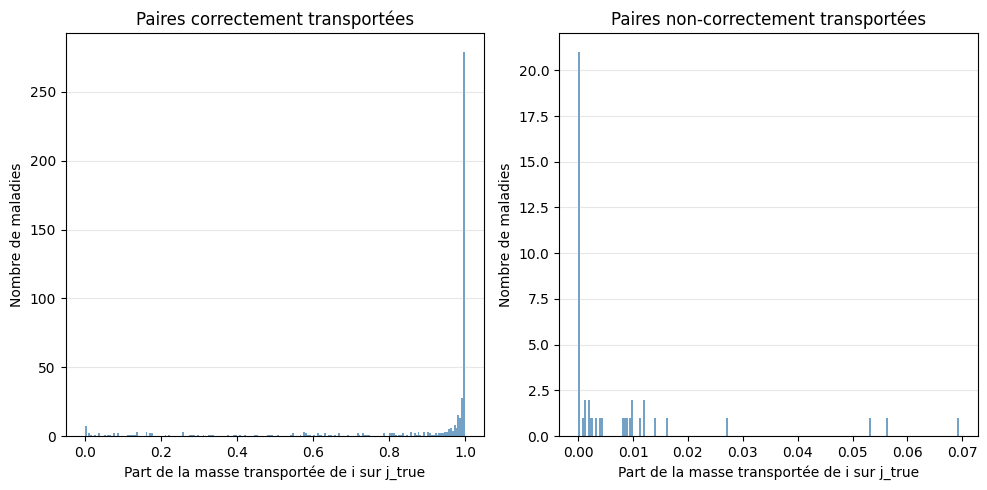

In [35]:
correct_pairs = [k for k, v in pairs_r.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(wass_ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=wass_ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
uncorrect_transported_share = [v for k, v in transported_share.items() if k in paires_zero_w]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Est-ce qu'il y a des termes HPO qui reviennent régulièrement parmi les maladies qui n'ont pas été 
# correctement transportées ?
zeros_terms_omim = {}
zeros_terms_orpha = {}
tot_omim = 0
tot_orpha = 0
for v in paires_zero_dict_w.values():
    for hp in v['omim']['terms']:
        if hp not in zeros_terms_omim.keys():
            zeros_terms_omim[hp]=1
        else:
            zeros_terms_omim[hp]+=1
        tot_omim+=1
    for hp in v['orpha']['terms']:
        if hp not in zeros_terms_orpha.keys():
            zeros_terms_orpha[hp]=1
        else:
            zeros_terms_orpha[hp]+=1
        tot_orpha+=1
zeros_terms_omim = {t:v/tot_omim for t, v in zeros_terms_omim.items()}
zeros_terms_orpha = {t:v/tot_orpha for t, v in zeros_terms_orpha.items()}

print("======= Top 5 des termes les + fréquents =======")
print("OMIM")
for k in sorted(zeros_terms_omim, key=zeros_terms_omim.get, reverse=True)[:5]:
    print(f"{k} - {np.round(zeros_terms_omim[k]*100, 2)} %")
print("ORPHA")
for k in sorted(zeros_terms_orpha, key=zeros_terms_orpha.get, reverse=True)[:5]:
    print(f"{k} - {np.round(zeros_terms_orpha[k]*100, 2)} %")

======= Top 5 des termes les + fréquents =======
OMIM
HP:0001249 - 2.43 %
HP:0000006 - 1.94 %
HP:0000007 - 1.82 %
HP:0001263 - 1.58 %
HP:0003593 - 1.22 %
ORPHA
HP:0001249 - 1.66 %
HP:0001250 - 1.42 %
HP:0000486 - 0.95 %
HP:0004322 - 0.83 %
HP:0001252 - 0.83 %


HP:0001249 : *intellectual disability*.
HP:0000006/HP:0000007 : *autosomal dominant/recessive inheritance*.
HP:0001250 : *Seizure*.
HP:0000486 : *Strabismus*


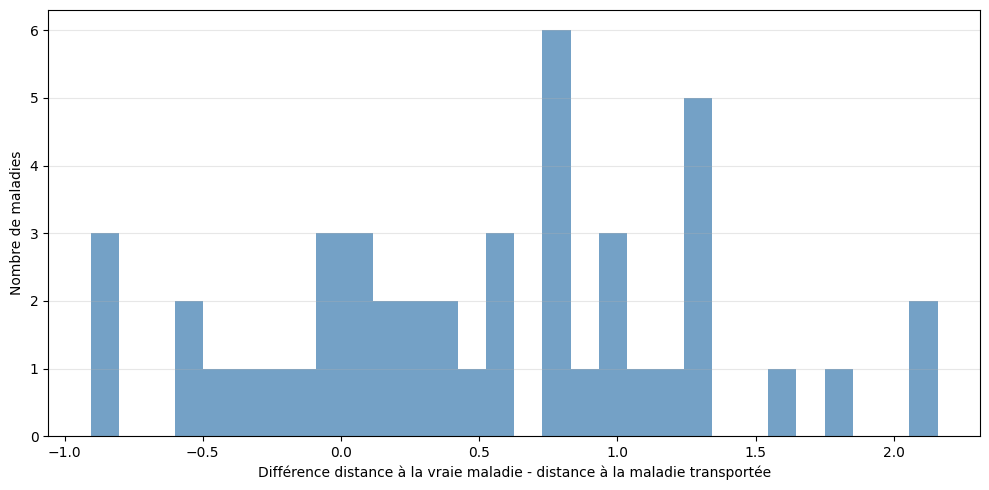

In [ ]:
# Cost gap : un petit écart de coût peu signifier des maladies similaires
cost_gap = [paires_zero_dict_w[k]["cost_true"]-paires_zero_dict_w[k]["cost_pred"] for k in paires_zero_dict_w.keys()]

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(cost_gap, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()